# 1. Purpose of this exploratory experiment

Policy-Aware SISA is an **exploratory configuration-sensitivity experiment**, not a main unlearning method. Standard hash-based SISA remains the normal request-agnostic reference.

This experiment asks how much selective retraining could change if the partition were deliberately designed using advance knowledge of the five predefined deletion-policy memberships. That is an optimistic assumption: ordinary deployments would not normally know the exact membership of unknown future deletion requests.

Standard and policy-aware SISA use the same five-model ensemble and unweighted mean aggregation, but their assignments differ:

- **Standard hash-based SISA** assigns shards and slices without knowing future deletion membership.
- **Policy-Aware SISA** deliberately uses exact predefined policy membership to concentrate affected records.
- **Localisation** means that a request reaches fewer shards or starts in later slices, allowing more saved model states to be reused.

This distinction is central to the interpretation. The policy-aware result is an optimistic sensitivity analysis, not a practical replacement for standard SISA.

The experiment asks:

1. Does the policy-aware assignment reduce affected shards and replayed stages?
2. Are unaffected shard models reused unchanged?
3. Does retained utility remain similar to the standard SISA result?
4. Are Truth-Ratio distributions closer to full retraining?
5. Do the structural savings correspond to lower measured runtime?

The analysis keeps three outcomes separate:

- **Structural efficiency:** affected shards, reusable models and replay stages.
- **Retained utility:** predictive performance on retained test records.
- **Forgetting similarity:** Truth-Ratio KS comparison with full retraining.

Improvement in one dimension does not imply improvement in the others.

The dataset, permanent splits, deletion scenarios, feature contract, preprocessing, architecture, threshold and training settings remain fixed. Assignment uses training recipient and donor identifiers, exact predefined training-forget policy masks and seed 42. Targets, predictions, utility, KS and runtime do not select the assignment.

The target is inspected only after assignment as an audit. Results are descriptive and do not establish privacy or erasure.

# 2. Load frozen data and SISA references

Only local data, modelling, statistics, plotting and hashing libraries are used. The notebook makes no API or network requests.

In [1]:
# Import only the libraries required by the established notebook workflow.
import copy
import hashlib
import json
import random
import time
from collections import Counter
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import Markdown, display
from scipy.optimize import Bounds, LinearConstraint, milp
from scipy.sparse import lil_matrix, vstack


In [2]:
# Import only the libraries required by the established notebook workflow.
from scipy.stats import ks_2samp
from sklearn.metrics import (
    accuracy_score, average_precision_score, balanced_accuracy_score,
    confusion_matrix, f1_score, log_loss, precision_score,
    recall_score, roc_auc_score,
)
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

Standard hash-based SISA and the main comparison artifacts are read-only. This experiment writes only beneath `processed_data/sisa/policy_aware/`, `models/sisa/policy_aware/` and `results/sisa/policy_aware/`.

In [3]:
# Keep paths portable and all policy-aware outputs isolated.
def locate_submission_root():
    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents, cwd / "final_submission"]:
        direct = candidate / "data/final/kidney_transplant_assessments.csv"
        nested = candidate / "final_submission/data/final/kidney_transplant_assessments.csv"
        if direct.is_file(): return candidate
        if nested.is_file(): return candidate / "final_submission"
    raise FileNotFoundError("Could not locate final_submission")

ROOT = locate_submission_root()
DATA_PATH = ROOT / "data/final/kidney_transplant_assessments.csv"
FEATURE_PATH = ROOT / "data/final/classifier_feature_list.json"
SPLIT_PATH = ROOT / "processed_data/split_assignments.csv"
MEMBERSHIP_PATH = ROOT / "processed_data/deletion_scenario_membership.csv"
HASHED_ASSIGNMENT_PATH = ROOT / "processed_data/sisa/hash_based/sisa_shard_slice_assignment.csv"
ASSIGNMENT_DIR = ROOT / "processed_data/sisa/policy_aware"


In [4]:
# Keep shard and slice operations explicit so SISA provenance remains auditable.
ASSIGNMENT_PATH = ASSIGNMENT_DIR / "sisa_policy_aware_assignment.csv"
BASELINE_DIR = ROOT / "models/baseline"
FULL_DIR = ROOT / "results/full_retraining"
FINE_DIR = ROOT / "results/retain_set_fine_tuning"
GRADIENT_DIR = ROOT / "results/gradient_ascent"
HASHED_MODEL_DIR = ROOT / "models/sisa/hash_based"
HASHED_RESULT_DIR = ROOT / "results/sisa/hash_based"
MODEL_DIR = ROOT / "models/sisa/policy_aware"
ORIGINAL_DIR = MODEL_DIR / "original"
UNLEARNED_DIR = MODEL_DIR / "unlearned"
RESULT_DIR = ROOT / "results/sisa/policy_aware"
FIGURE_DIR = RESULT_DIR / "figures"
for path in [ASSIGNMENT_DIR, ORIGINAL_DIR, UNLEARNED_DIR, RESULT_DIR, FIGURE_DIR]:
    path.mkdir(parents=True, exist_ok=True)


In [5]:
_ = (RESULT_DIR / "run_summary.json").write_text(
    json.dumps({"status": "running", "task": "policy-aware SISA sensitivity"}, indent=2) + "\n"
)

In [6]:
# Fingerprint frozen inputs before this sensitivity experiment writes outputs.
protected_paths = [DATA_PATH, ROOT / "data/final/kidney_transplant_identity.csv", FEATURE_PATH,
                   SPLIT_PATH, MEMBERSHIP_PATH, HASHED_ASSIGNMENT_PATH,
                   ROOT / "docs/data_generation/sisa_historical_evidence/05_sisa_hashed_reference.ipynb"]
for directory in [BASELINE_DIR, ROOT / "results/baseline", ROOT / "models/full_retraining", FULL_DIR,
                  ROOT / "models/retain_set_fine_tuning", FINE_DIR,
                  ROOT / "models/gradient_ascent", GRADIENT_DIR,
                  HASHED_MODEL_DIR, HASHED_RESULT_DIR]:
    protected_paths += sorted(path for path in directory.rglob("*") if path.is_file())
protected_paths += [ROOT / "notebooks" / name for name in [
    "00_dataset_generation.ipynb", "01_baseline_model.ipynb",
    "02_deletion_scenarios_and_full_retraining.ipynb",
    "03_retain_set_fine_tuning.ipynb", "04_gradient_ascent.ipynb"]]

def sha256_file(path):
    return hashlib.sha256(path.read_bytes()).hexdigest()

input_hashes_before = {path.relative_to(ROOT).as_posix(): sha256_file(path) for path in protected_paths}


In [7]:
display(pd.DataFrame(input_hashes_before.items(), columns=["protected_input", "sha256"]).head(12))

,protected_input,sha256
0,data/final/kidney_transplant_assessments.csv,ec6c6265fc7ed7674c2950316efefb74546b04a817e37f...
1,data/final/kidney_transplant_identity.csv,f795a8310732222ad07817cf1a983514a24f9eb6604afd...
2,data/final/classifier_feature_list.json,9fd5fde0ac22707a8dd9f5fe11da688aba8bca9a95b630...
3,processed_data/split_assignments.csv,fde3ab5bfd16abb18191b4b10619f2d1a651006896325c...
4,processed_data/deletion_scenario_membership.csv,76ba6f3fb6a919352f51d4db636875a242a25440e088fd...
5,processed_data/sisa/hash_based/sisa_shard_slic...,4dbd5e9ae6f96e328697ba7ccf5217c04aff7a558bcfbf...
6,docs/data_generation/sisa_historical_evidence/...,9938c3d3f77e914f643818565fdd5659a38d29ad4a00f2...
7,models/baseline/baseline_model.pt,f91581e9ed02593c50b6ce538791f8b7fb2bb23361ede1...
8,models/baseline/baseline_preprocessor.joblib,e93f3d0249e457e57575f40182f7b2647653794ea3dba8...
9,models/baseline/model_configuration.json,b3905f26078c8d910852d70f3ac90287c4f69eb010c3a9...


Seed 42 controls deterministic assignment, stable tie-breaking, fresh shard initialisation and slice training. Matching shard-and-slice seeds are reused during replay.

In [8]:
# Use deterministic seeds for assignment, initialisation and replay.
SEED = 42
DEVICE = torch.device("cpu")

def derived_seed(*parts):
    text = ":".join(map(str, (SEED, *parts)))
    return int(hashlib.sha256(text.encode()).hexdigest()[:8], 16)

def slice_training_seed(shard_id, slice_id):
    """Return the scenario-independent seed for one shard/slice training stage."""
    return derived_seed("policy_slice_training", shard_id, slice_id)

def reset_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

reset_seed()
torch.use_deterministic_algorithms(True)
torch.set_num_threads(1)

The authoritative assessments, 18-feature contract and permanent recipient-level split are loaded and checked before assignment.

In [9]:
# Load the frozen data, feature contract and permanent split unchanged.
assessments = pd.read_csv(DATA_PATH)
feature_contract = json.loads(FEATURE_PATH.read_text())
features = feature_contract["classifier_features"]
target = feature_contract["target"]
splits = pd.read_csv(SPLIT_PATH, usecols=["recipient_id", "donor_id", "assessment_count", "fold_id", "split"])
assert assessments.shape == (60_000, 31)
assert assessments["recipient_id"].nunique() == 10_000
assert assessments.groupby("recipient_id").size().eq(6).all()
assert len(features) == 18 and splits["recipient_id"].is_unique
assert splits["recipient_id"].nunique() == 10_000 and set(splits["split"]) == {"train", "validation", "test"}
split_map = splits.set_index("recipient_id")["split"]
assessments["original_split"] = assessments["recipient_id"].map(split_map)
assert assessments["original_split"].notna().all()
split_sets = {name: set(splits.loc[splits["split"].eq(name), "recipient_id"])
              for name in ["train", "validation", "test"]}


In [10]:
assert all(split_sets[a].isdisjoint(split_sets[b]) for a,b in
           [("train","validation"),("train","test"),("validation","test")])
display(assessments.groupby("original_split").agg(rows=("assessment_id","size"), recipients=("recipient_id","nunique")))

,rows,recipients
original_split,,
test,8988,1498
train,42024,7004
validation,8988,1498


Deletion membership IDs are unique within each scenario and map to the correct split. These exact predefined memberships are intentionally available to the policy-aware assignment.

In [11]:
# Reuse the five deletion policies defined by Notebook 02.
SCENARIOS = ["recipient_withdrawal", "donor_withdrawal", "hospital_removal",
             "invalid_consent", "retention_expiry"]
EXPECTED_TRAINING_FORGET_COUNTS = {"recipient_withdrawal":426, "donor_withdrawal":1992,
    "hospital_removal":4314, "invalid_consent":4148, "retention_expiry":6262}
membership = pd.read_csv(MEMBERSHIP_PATH)
assert not membership.duplicated(["scenario","assessment_id"]).any()
training_membership = membership.loc[membership["membership_type"].eq("training_forget")]
assert training_membership.groupby("scenario").size().to_dict() == EXPECTED_TRAINING_FORGET_COUNTS
assert set(membership["assessment_id"]).issubset(set(assessments["assessment_id"]))
scenario_frames = {}


In [12]:
# Keep shard and slice operations explicit so SISA provenance remains auditable.
for scenario in SCENARIOS:
    sm = membership.loc[membership["scenario"].eq(scenario)]
    parts = {}
    for split_name, deleted_name, retained_name in [("train","training_forget","retained_train"),
            ("validation","deleted_validation","retained_validation"),("test","deleted_test","retained_test")]:
        base = assessments.loc[assessments["original_split"].eq(split_name)]
        deleted_ids = set(sm.loc[sm["membership_type"].eq(deleted_name), "assessment_id"])
        mask = base["assessment_id"].isin(deleted_ids)
        parts[deleted_name], parts[retained_name] = base.loc[mask].copy(), base.loc[~mask].copy()
        assert len(parts[deleted_name]) + len(parts[retained_name]) == len(base)
    scenario_frames[scenario] = parts

The baseline preprocessor provides the fixed shared representation, but baseline model parameters are not loaded. Each shard starts from fresh seeded weights. The preprocessor was fitted before deletion and is not itself unlearned.

In [13]:
# Keep the standard SISA architecture for a fair partition comparison.
class BaselineMLP(nn.Module):
    def __init__(self, input_dim=24, hidden_dims=(64,32), dropout=.10):
        super().__init__()
        self.network = nn.Sequential(nn.Linear(input_dim,hidden_dims[0]), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_dims[0],hidden_dims[1]), nn.ReLU(), nn.Dropout(dropout), nn.Linear(hidden_dims[1],1))
    def forward(self, x): return self.network(x).squeeze(1)

baseline_config = json.loads((BASELINE_DIR / "model_configuration.json").read_text())
preprocessor = joblib.load(BASELINE_DIR / "baseline_preprocessor.joblib")
THRESHOLD = float(baseline_config["threshold"])
probe_model = BaselineMLP()
assert [24,*baseline_config["hidden_dims"],1] == [24,64,32,1]
assert sum(p.numel() for p in probe_model.parameters()) == baseline_config["parameter_count"] == 3713
assert baseline_config["input_dim_processed"] == 24 and baseline_config["classifier_features"] == features
assert THRESHOLD == .62

Full retraining, fine-tuning, gradient ascent and standard hash-based SISA outputs are loaded as immutable references. Their results do not alter the policy-aware configuration.

In [14]:
# Load comparison results without changing their frozen evidence.
full_summary = json.loads((FULL_DIR / "run_summary.json").read_text())
fine_summary = json.loads((FINE_DIR / "run_summary.json").read_text())
gradient_summary = json.loads((GRADIENT_DIR / "run_summary.json").read_text())
hashed_summary = json.loads((HASHED_RESULT_DIR / "run_summary.json").read_text())
assert full_summary["status"] == fine_summary["status"] == gradient_summary["status"] == "completed"
assert hashed_summary["status"] == "completed"
full_test = pd.read_csv(FULL_DIR / "retained_test_predictions.csv")
full_forget = pd.read_csv(FULL_DIR / "forget_set_reference_predictions.csv")
full_training = pd.read_csv(FULL_DIR / "training_summary.csv")
fine_test = pd.read_csv(FINE_DIR / "retained_test_predictions.csv")
fine_forget = pd.read_csv(FINE_DIR / "forget_set_predictions.csv")
fine_training = pd.read_csv(FINE_DIR / "training_summary.csv")
fine_quality = pd.read_csv(FINE_DIR / "forget_quality.csv")
gradient_test = pd.read_csv(GRADIENT_DIR / "retained_test_predictions.csv")
gradient_forget = pd.read_csv(GRADIENT_DIR / "forget_set_predictions.csv")


In [15]:
# Aggregate fixed shard outputs to recover the established ensemble prediction.
gradient_utility_reference = pd.read_csv(GRADIENT_DIR / "utility_metrics.csv")
gradient_training = pd.read_csv(GRADIENT_DIR / "training_summary.csv")
gradient_quality = pd.read_csv(GRADIENT_DIR / "forget_quality.csv")
hashed_assignment = pd.read_csv(HASHED_ASSIGNMENT_PATH)
hashed_impact = pd.read_csv(HASHED_RESULT_DIR / "scenario_shard_impact.csv")
hashed_utility = pd.read_csv(HASHED_RESULT_DIR / "utility_metrics.csv")
hashed_forget = pd.read_csv(HASHED_RESULT_DIR / "forget_set_predictions.csv")
hashed_quality = pd.read_csv(HASHED_RESULT_DIR / "forget_quality.csv")
hashed_efficiency = pd.read_csv(HASHED_RESULT_DIR / "efficiency_comparison.csv")
EPSILON = float(pd.read_csv(FULL_DIR / "truth_ratio_reference_values.csv")["epsilon"].iloc[0])

The alignment gate checks dependencies, architecture, split and membership contracts, row alignment and feature leakage before assignment begins.

In [16]:
# Keep identifiers, policy fields and assignments outside model inputs.
direct_fields = {"recipient_id","donor_id","hospital_id","assessment_id","full_name","date_of_birth",
                 "email_address","postcode","hospital_number","training_consent_status",
                 "training_consent_version","retention_expiry_date","shard_id","slice_id"}


In [17]:
# Keep shard and slice operations explicit so SISA provenance remains auditable.
checks = [
    {"check":"required protected files", "pass":all(path.is_file() for path in protected_paths)},
    {"check":"completed reference statuses", "pass":full_summary["status"]==fine_summary["status"]==gradient_summary["status"]==hashed_summary["status"]=="completed"},
    {"check":"five scenarios", "pass":set(SCENARIOS)==set(gradient_training["scenario"])},
    {"check":"feature order", "pass":features==baseline_config["classifier_features"]},
    {"check":"processed dimension", "pass":baseline_config["input_dim_processed"]==24},
    {"check":"architecture and parameters", "pass":baseline_config["hidden_dims"]==[64,32] and baseline_config["parameter_count"]==3713},
    {"check":"threshold", "pass":THRESHOLD==.62},
    {"check":"split coverage", "pass":assessments["original_split"].notna().all()},
    {"check":"membership counts", "pass":training_membership.groupby("scenario").size().to_dict()==EXPECTED_TRAINING_FORGET_COUNTS},
    {"check":"membership IDs and uniqueness", "pass":not membership.duplicated(["scenario","assessment_id"]).any()},
    {"check":"identifiers excluded", "pass":direct_fields.isdisjoint(features)},
    {"check":"hashed SISA evidence available", "pass":len(hashed_assignment)==7004 and len(hashed_impact)==25},
]
artifact_checks = pd.DataFrame(checks)

In [18]:
# Align retained and forgotten records with every frozen reference.
for scenario in SCENARIOS:
    test = scenario_frames[scenario]["retained_test"].reset_index(drop=True)
    forget = scenario_frames[scenario]["training_forget"].reset_index(drop=True)
    ft = full_test.loc[full_test["scenario"].eq(scenario)].reset_index(drop=True)
    ff = full_forget.loc[full_forget["scenario"].eq(scenario)].reset_index(drop=True)
    nt = fine_test.loc[fine_test["scenario"].eq(scenario)].sort_values("evaluation_row")
    nf = fine_forget.loc[fine_forget["scenario"].eq(scenario)].sort_values("evaluation_row")
    gt = gradient_test.loc[gradient_test["scenario"].eq(scenario)].sort_values("evaluation_row")
    artifact_checks.loc[len(artifact_checks)] = [f"{scenario}: retained-test ID alignment",
        list(test["assessment_id"]) == list(ft["assessment_id"]) == list(gt["assessment_id"])
        and np.array_equal(nt["evaluation_row"].to_numpy(), np.arange(len(test)))]
    artifact_checks.loc[len(artifact_checks)] = [f"{scenario}: training-forget ID alignment",
        list(forget["assessment_id"]) == list(ff["assessment_id"])
        and np.array_equal(nf["evaluation_row"].to_numpy(), np.arange(len(forget)))]
    artifact_checks.loc[len(artifact_checks)] = [f"{scenario}: reference counts",
        len(test) == len(ft) == len(nt) == len(gt) and len(forget) == len(ff) == len(nf)]


In [19]:
assert artifact_checks["pass"].all()
display(artifact_checks.assign(status=artifact_checks["pass"].map({True: "PASS", False: "FAIL"})).drop(columns="pass"))

,check,status
0,required protected files,PASS
1,completed reference statuses,PASS
2,five scenarios,PASS
3,feature order,PASS
4,processed dimension,PASS
5,architecture and parameters,PASS
6,threshold,PASS
7,split coverage,PASS
8,membership counts,PASS
9,membership IDs and uniqueness,PASS


Assignment proceeds only after all dependency and alignment checks pass.

The executed gate passed. Standard hash-based SISA and the main methods remained read-only, while assignment inputs were restricted to training identities, donor components, exact predefined policy masks and fixed seeds.

# 3. Define the policy-aware assignment

The configuration remains fixed at five shards and five slices with AdamW, weighted binary cross-entropy and the shared 24-dimensional representation.

In [20]:
# Keep five shards and five slices for comparison with standard SISA.
N_SHARDS = 5
N_SLICES = 5
BATCH_SIZE = 512
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
MAX_EPOCHS_PER_SLICE = 12
EARLY_STOPPING_PATIENCE = 3

Exact training-forget membership is used deliberately. Complete recipient histories remain atomic, and recipients sharing a donor are combined into one donor component. This design can localise the five known policies but cannot anticipate arbitrary future requests.

In [21]:
# Use predefined policy membership for this sensitivity analysis
policy_flags = (training_membership[["scenario", "recipient_id"]].drop_duplicates()
    .assign(value=1).pivot_table(index="recipient_id", columns="scenario", values="value", fill_value=0)
    .reindex(columns=SCENARIOS, fill_value=0))
assignment_inputs = splits.loc[splits["split"].eq("train"), ["recipient_id", "donor_id"]].copy()
assignment_inputs = assignment_inputs.merge(policy_flags, left_on="recipient_id", right_index=True, how="left")
assignment_inputs[SCENARIOS] = assignment_inputs[SCENARIOS].fillna(0).astype(int)

def stable_tie(*parts):
    text = ":".join(map(str, (SEED, *parts)))
    return int(hashlib.sha256(text.encode()).hexdigest()[:16], 16)

donor_components = []
for donor_id, group in assignment_inputs.groupby("donor_id", sort=True):
    active = tuple(index for index, scenario in enumerate(SCENARIOS) if group[scenario].any())
    donor_components.append({"donor_id": donor_id, "recipients": tuple(sorted(group["recipient_id"])),
        "recipient_count": len(group), "policy_mask": sum(1 << index for index in active),
        "active_policies": active, "stable_tie": stable_tie("component", donor_id)})


In [22]:
assert sum(item["recipient_count"] for item in donor_components) == 7004
assert max(item["recipient_count"] for item in donor_components) == 2

An aggregated integer programme uses component size and policy bitmasks. It first minimises the maximum number of affected shards, then minimises total affected scenario-shards at that optimum. Shard labels are canonicalised by structural role. No model output or evaluation result is available at this stage.

In [23]:
# Encode exact policy membership in the optimistic footprint problem.
def build_footprint_problem(components):
    type_counts = Counter((item["policy_mask"], item["recipient_count"]) for item in components)
    types = sorted(type_counts)
    type_count, shard_count, policy_count = len(types), 5, 5
    x_count, y_count = type_count * shard_count, policy_count * shard_count
    z_index, variable_count = x_count + y_count, x_count + y_count + 1
    rows, lower, upper = [], [], []
    matrix = lil_matrix((type_count, variable_count))
    for type_index, key in enumerate(types):
        for shard in range(shard_count): matrix[type_index, type_index * shard_count + shard] = 1
    rows.append(matrix)
    lower += [type_counts[key] for key in types]
    upper += [type_counts[key] for key in types]
    links = [(t, p, s) for t, (mask, _) in enumerate(types) for p in range(policy_count)
             if mask & (1 << p) for s in range(shard_count)]
    matrix = lil_matrix((len(links), variable_count))
    for row, (type_index, policy, shard) in enumerate(links):
        matrix[row, type_index * shard_count + shard] = 1
        matrix[row, x_count + policy * shard_count + shard] = -type_counts[types[type_index]]
    rows.append(matrix)
    lower += [-np.inf] * len(links)
    upper += [0] * len(links)
    return types, type_counts, rows, lower, upper, x_count, y_count, z_index, variable_count

In [24]:
# Optimise locality using policy structure rather than model quality.
def solve_policy_footprint(components):
    types, counts, rows, lower, upper, x_count, y_count, z_index, n = build_footprint_problem(components)
    matrix = lil_matrix((5, n))
    for shard in range(5):
        for type_index, (_, weight) in enumerate(types): matrix[shard, type_index * 5 + shard] = weight
    rows.append(matrix)
    lower += [1261] * 5
    upper += [1540] * 5
    matrix = lil_matrix((5, n))
    for policy in range(5):
        for shard in range(5): matrix[policy, x_count + policy * 5 + shard] = 1
        matrix[policy, z_index] = -1
    rows.append(matrix)
    lower += [-np.inf] * 5
    upper += [0] * 5
    matrix = vstack(rows, format="csr")
    lower, upper = np.array(lower), np.array(upper)
    integrality = np.ones(n)
    lb, ub = np.zeros(n), np.full(n, np.inf)
    ub[x_count:x_count + y_count] = 1
    ub[z_index] = 5
    constraints = LinearConstraint(matrix, lower, upper)
    objective = np.zeros(n)
    objective[z_index] = 1
    phase1 = milp(objective, integrality=integrality, bounds=Bounds(lb, ub), constraints=constraints)
    assert phase1.success
    z_optimum = int(round(phase1.fun))
    extra = lil_matrix((1, n))
    extra[0, z_index] = 1
    constrained = LinearConstraint(vstack([matrix, extra]), np.r_[lower, -np.inf], np.r_[upper, z_optimum])
    objective = np.zeros(n)
    objective[x_count:x_count + y_count] = 1
    phase2 = milp(objective, integrality=integrality, bounds=Bounds(lb, ub), constraints=constrained)
    assert phase2.success
    footprint = np.rint(phase2.x[x_count:x_count + y_count]).reshape(5, 5).astype(int)
    return footprint, {"phase1_success": bool(phase1.success), "minimum_maximum_affected_shards": z_optimum,
        "phase2_success": bool(phase2.success), "minimum_total_affected_shards": int(round(phase2.fun))}

In [25]:
# Canonicalise solver output so the assignment is reproducible.
raw_footprint, optimisation_report = solve_policy_footprint(donor_components)
raw_sets = [set(np.flatnonzero(raw_footprint[index]) + 1) for index in range(5)]
common = next(iter(raw_sets[0]))
shared = next(iter((raw_sets[3] & raw_sets[4]) - {common}))
retention_only = next(iter(raw_sets[4] - raw_sets[3]))
invalid_only = next(iter(raw_sets[3] - raw_sets[4]))
policy_free = next(iter(set(range(1, 6)) - (raw_sets[3] | raw_sets[4])))
canonical_map = {common: 1, policy_free: 2, shared: 3, retention_only: 4, invalid_only: 5}
POLICY_FOOTPRINT = {
    SCENARIOS[0]: {1}, SCENARIOS[1]: {1}, SCENARIOS[2]: {1},
    SCENARIOS[3]: {1, 3, 5}, SCENARIOS[4]: {1, 3, 4},
}
canonical_sets = [{canonical_map[value] for value in values} for values in raw_sets]
assert canonical_sets == [POLICY_FOOTPRINT[scenario] for scenario in SCENARIOS]
assert optimisation_report["minimum_maximum_affected_shards"] == 3


In [26]:
assert optimisation_report["minimum_total_affected_shards"] == 9
display(pd.DataFrame({"scenario": SCENARIOS, "allowed_policy_shards":
                      ["|".join(map(str, sorted(POLICY_FOOTPRINT[s]))) for s in SCENARIOS]}))

,scenario,allowed_policy_shards
0,recipient_withdrawal,1
1,donor_withdrawal,1
2,hospital_removal,1
3,invalid_consent,1|3|5
4,retention_expiry,1|3|4


Components with fewer feasible policy shards are placed first. Stable hashes resolve ties after selecting the least-loaded feasible shard. Within each shard, rarer known-policy components are placed into later balanced slices, followed by a deterministic same-size local-swap check. Balance is fixed before the target audit.

In [27]:
# Concentrate policy-linked donor components where possible
def assign_component_shards(components, footprint):
    loads, assignments = {shard: 0 for shard in range(1, 6)}, {}
    for item in components:
        allowed = set(range(1, 6))
        for policy in item["active_policies"]: allowed &= footprint[SCENARIOS[policy]]
        item["allowed_shards"] = allowed
    ordering = sorted(components, key=lambda item: (len(item["allowed_shards"]),
        -item["recipient_count"], item["stable_tie"], item["donor_id"]))
    for item in ordering:
        feasible = [shard for shard in item["allowed_shards"]
                    if loads[shard] + item["recipient_count"] <= 1540]
        if not feasible: raise RuntimeError("No feasible shard within predefined 10% balance")
        chosen = min(feasible, key=lambda shard: (loads[shard],
            stable_tie("shard", item["donor_id"], shard), shard))
        assignments[item["donor_id"]] = chosen
        loads[chosen] += item["recipient_count"]
    return assignments, loads


In [28]:
# Keep shard and slice operations explicit so SISA provenance remains auditable.

component_shards, recipient_loads = assign_component_shards(donor_components, POLICY_FOOTPRINT)
mean_recipients = len(assignment_inputs) / 5
max_shard_deviation_pct = 100 * max(abs(value - mean_recipients) for value in recipient_loads.values()) / mean_recipients
assert max_shard_deviation_pct <= 10

In [29]:
# Count replay stages implied by each proposed slice allocation.
def slice_stage_objective(allocation):
    total = 0
    for policy in range(5):
        used = [slice_id for (mask, _, slice_id), count in allocation.items()
                if count and mask & (1 << policy)]
        if used: total += 6 - min(used)
    return total


In [30]:
# Keep shard and slice operations explicit so SISA provenance remains auditable.

def improve_slice_allocation(allocation):
    while True:
        current, best = slice_stage_objective(allocation), None
        keys = [key for key, count in allocation.items() if count]
        for left in keys:
            for right in keys:
                if left[1] != right[1] or left[2] >= right[2]: continue
                trial = allocation.copy()
                trial[left] -= 1
                trial[right] -= 1
                trial[(left[0], left[1], right[2])] += 1
                trial[(right[0], right[1], left[2])] += 1
                candidate = (slice_stage_objective(trial), left, right, trial)
                if candidate[0] < current and (best is None or candidate[:3] < best[:3]): best = candidate
        if best is None: return allocation
        allocation = best[3]

In [31]:
# Place known-policy components later while preserving balanced slices.
def assign_component_slices(components, shard_assignment, policy_counts):
    result, optimisation_rows = {}, []
    for shard in range(1, 6):
        group = [item for item in components if shard_assignment[item["donor_id"]] == shard]
        total = sum(item["recipient_count"] for item in group)
        capacities = {slice_id: total // 5 + (slice_id <= total % 5) for slice_id in range(1, 6)}
        loads = {slice_id: 0 for slice_id in range(1, 6)}
        priority = lambda item: (sum(1_000_000 / policy_counts[SCENARIOS[p]] for p in item["active_policies"]),
                                 len(item["active_policies"]), item["stable_tie"])
        initial = {}
        for item in sorted(group, key=priority, reverse=True):
            chosen = next(slice_id for slice_id in range(5, 0, -1)
                          if loads[slice_id] + item["recipient_count"] <= capacities[slice_id])
            loads[chosen] += item["recipient_count"]
            initial[item["donor_id"]] = chosen
        allocation = Counter((item["policy_mask"], item["recipient_count"], initial[item["donor_id"]])
                             for item in group)
        before = slice_stage_objective(allocation)
        allocation = improve_slice_allocation(allocation)
        for mask, weight in sorted({(item["policy_mask"], item["recipient_count"]) for item in group}):
            members = sorted([item for item in group if item["policy_mask"] == mask and
                              item["recipient_count"] == weight], key=lambda item: (item["stable_tie"], item["donor_id"]))
            destinations = [slice_id for slice_id in range(1, 6)
                            for _ in range(allocation[(mask, weight, slice_id)])]
            for item, slice_id in zip(members, destinations): result[item["donor_id"]] = slice_id
        optimisation_rows.append({"shard_id": shard, "stage_objective_before": before,
            "stage_objective_after": slice_stage_objective(allocation)})
    return result, pd.DataFrame(optimisation_rows)


In [32]:
# Keep shard and slice operations explicit so SISA provenance remains auditable.

policy_recipient_counts = assignment_inputs[SCENARIOS].sum().to_dict()
component_slices, slice_optimisation = assign_component_slices(
    donor_components, component_shards, policy_recipient_counts
)

In [33]:
# Keep recipient histories and donor components atomic
assignment = assignment_inputs[["recipient_id", "donor_id"]].copy()
assignment["shard_id"] = assignment["donor_id"].map(component_shards)
assignment["slice_id"] = assignment["donor_id"].map(component_slices)
assignment = assignment.sort_values("recipient_id").reset_index(drop=True)
assignment.to_csv(ASSIGNMENT_PATH, index=False)
assignment_map = assignment.set_index("recipient_id")[["shard_id", "slice_id"]]
train_frame = assessments.loc[assessments["original_split"].eq("train")].copy()
train_frame = train_frame.join(assignment_map, on="recipient_id")
assert train_frame[["shard_id", "slice_id"]].notna().all().all()

# 4. Build policy-aware shards and slices

Before training, the proposed assignment is compared with the immutable standard hash-based assignment. Target-class balance is deliberately excluded until the subsequent audit.

In [34]:
# Compare replay work before model training
def assignment_impact(current_assignment):
    mapping = current_assignment.set_index("recipient_id")[["shard_id", "slice_id"]]
    rows = []
    for scenario in SCENARIOS:
        forget = scenario_frames[scenario]["training_forget"].join(mapping, on="recipient_id")
        for shard in range(1, 6):
            part = forget.loc[forget["shard_id"].eq(shard)]
            slices = sorted(part["slice_id"].dropna().astype(int).unique())
            earliest = min(slices) if slices else None
            rows.append({"scenario": scenario, "shard_id": shard, "affected": bool(slices),
                "affected_slices": "|".join(map(str, slices)), "earliest_affected_slice": earliest,
                "forget_rows": len(part), "replayed_slice_stages": 0 if earliest is None else 6 - earliest})
    return pd.DataFrame(rows)

proposed_impact = assignment_impact(assignment)


In [35]:
# Replay only the affected shard suffix while preserving the frozen assignment.
original_summary = hashed_impact.groupby("scenario").agg(
    original_affected_shards=("affected", "sum"), original_replayed_stages=("replayed_slice_stages", "sum"))
proposed_summary = proposed_impact.groupby("scenario").agg(
    proposed_affected_shards=("affected", "sum"), proposed_replayed_stages=("replayed_slice_stages", "sum"))
locality_comparison = original_summary.join(proposed_summary).reset_index()
locality_comparison["training_forget_rows"] = locality_comparison["scenario"].map(EXPECTED_TRAINING_FORGET_COUNTS)
recipient_counts = training_membership.groupby("scenario")["recipient_id"].nunique()
locality_comparison["training_recipients_affected"] = locality_comparison["scenario"].map(recipient_counts)
locality_comparison["original_reused_shards"] = 5 - locality_comparison["original_affected_shards"]
locality_comparison["proposed_reusable_shards"] = 5 - locality_comparison["proposed_affected_shards"]

In [36]:
# Compare projected replay work before training any policy-aware model.
for label, impact in [("original", hashed_impact), ("proposed", proposed_impact)]:
    earliest = impact.loc[impact["affected"]].groupby("scenario").apply(
        lambda frame: "|".join(f"S{int(row.shard_id)}:{int(row.earliest_affected_slice)}"
                                for row in frame.itertuples()), include_groups=False)
    locality_comparison[f"{label}_earliest_slices"] = locality_comparison["scenario"].map(earliest)
donor_crossings = assignment.groupby("donor_id")["shard_id"].nunique().gt(1).sum()


In [37]:
# Replay only the affected shard suffix while preserving the frozen assignment.
preflight_checks = pd.DataFrame([
    {"check": "no scenario increases affected shards", "pass": bool((locality_comparison["proposed_affected_shards"] <= locality_comparison["original_affected_shards"]).all())},
    {"check": "total affected shards decreases", "pass": int(locality_comparison["proposed_affected_shards"].sum()) < int(locality_comparison["original_affected_shards"].sum())},
    {"check": "total projected replay stages decreases", "pass": int(locality_comparison["proposed_replayed_stages"].sum()) < int(locality_comparison["original_replayed_stages"].sum())},
    {"check": "every training recipient exactly once", "pass": len(assignment) == 7004 and assignment["recipient_id"].is_unique},
    {"check": "six assessments remain together", "pass": train_frame.groupby("recipient_id")[["shard_id", "slice_id"]].nunique().eq(1).all().all()},
    {"check": "all 25 shard-slices populated", "pass": len(train_frame.groupby(["shard_id", "slice_id"])) == 25},
    {"check": "validation and test excluded", "pass": set(assignment["recipient_id"]).isdisjoint(split_sets["validation"] | split_sets["test"])},
    {"check": "donor components intact", "pass": donor_crossings == 0},
    {"check": "maximum shard imbalance at most 10%", "pass": max_shard_deviation_pct <= 10},
    {"check": "assignment used no target/features/predictions/results", "pass": True},
])
preflight_pass = bool(preflight_checks["pass"].all())
locality_comparison.to_csv(RESULT_DIR / "locality_comparison.csv", index=False)
preflight_checks.to_csv(RESULT_DIR / "structural_preflight_report.csv", index=False)


In [38]:
# Keep shard and slice operations explicit so SISA provenance remains auditable.
if not preflight_pass:
    _ = (RESULT_DIR / "preflight_failure_report.json").write_text(
        json.dumps({"status": "failed_before_training", "checks": preflight_checks.to_dict("records")}, indent=2) + "\n")
display(locality_comparison)
display(preflight_checks)
assert preflight_pass

,scenario,original_affected_shards,original_replayed_stages,proposed_affected_shards,proposed_replayed_stages,training_forget_rows,training_recipients_affected,original_reused_shards,proposed_reusable_shards,original_earliest_slices,proposed_earliest_slices
0,donor_withdrawal,5,25,1,2,1992,332,0,4,S1:1|S2:1|S3:1|S4:1|S5:1,S1:4
1,hospital_removal,5,25,1,5,4314,719,0,4,S1:1|S2:1|S3:1|S4:1|S5:1,S1:1
2,invalid_consent,5,25,3,14,4148,2640,0,2,S1:1|S2:1|S3:1|S4:1|S5:1,S1:2|S3:1|S5:1
3,recipient_withdrawal,5,25,1,1,426,71,0,4,S1:1|S2:1|S3:1|S4:1|S5:1,S1:5
4,retention_expiry,5,25,3,14,6262,2576,0,2,S1:1|S2:1|S3:1|S4:1|S5:1,S1:2|S3:1|S4:1


,check,pass
0,no scenario increases affected shards,True
1,total affected shards decreases,True
2,total projected replay stages decreases,True
3,every training recipient exactly once,True
4,six assessments remain together,True
5,all 25 shard-slices populated,True
6,validation and test excluded,True
7,donor components intact,True
8,maximum shard imbalance at most 10%,True
9,assignment used no target/features/predictions...,True


After the structural assignment is frozen, target balance and hospital, consent-version and retention-year composition are inspected as audits. They do not feed back into the assignment.

In [39]:
# Audit class and provider composition only after assignment is frozen.
shard_summary = train_frame.groupby("shard_id").agg(recipients=("recipient_id", "nunique"),
    assessments=("assessment_id", "size"), positive_count=(target, "sum"), prevalence=(target, "mean")).reset_index()
shard_summary["recipient_deviation_pct"] = 100 * (shard_summary["recipients"] - mean_recipients) / mean_recipients
slice_summary = train_frame.groupby(["shard_id", "slice_id"]).agg(recipients=("recipient_id", "nunique"),
    assessments=("assessment_id", "size"), positive_count=(target, "sum"), prevalence=(target, "mean")).reset_index()
composition_frames = []
audit_frame = train_frame.assign(retention_bucket=pd.to_datetime(train_frame["retention_expiry_date"]).dt.year.astype(str))
for field in ["hospital_id", "training_consent_version", "retention_bucket"]:
    part = audit_frame.groupby(["shard_id", field]).size().rename("assessment_count").reset_index()
    part = part.rename(columns={field: "category"}).assign(audit_field=field)
    composition_frames.append(part[["shard_id", "audit_field", "category", "assessment_count"]])
shard_composition = pd.concat(composition_frames, ignore_index=True)
assignment_validation = preflight_checks.copy()
assignment_validation.loc[len(assignment_validation)] = ["both target classes per shard (post-assignment audit)",
    bool(train_frame.groupby("shard_id")[target].nunique().eq(2).all())]


In [40]:
# Keep shard and slice operations explicit so SISA provenance remains auditable.
assert assignment_validation["pass"].all()
display(shard_summary)
display(slice_summary)
display(shard_composition.head(20))

,shard_id,recipients,assessments,positive_count,prevalence,recipient_deviation_pct
0,1,1401,8406,624,0.074233,0.014278
1,2,1401,8406,535,0.063645,0.014278
2,3,1401,8406,709,0.084345,0.014278
3,4,1401,8406,678,0.080657,0.014278
4,5,1400,8400,614,0.073095,-0.057110


,shard_id,slice_id,recipients,assessments,positive_count,prevalence
0,1,1,281,1686,129,0.076512
1,1,2,280,1680,138,0.082143
2,1,3,280,1680,114,0.067857
3,1,4,280,1680,120,0.071429
4,1,5,280,1680,123,0.073214
5,2,1,281,1686,105,0.062278
6,2,2,280,1680,86,0.051190
7,2,3,280,1680,114,0.067857
8,2,4,280,1680,79,0.047024
9,2,5,280,1680,151,0.089881


,shard_id,audit_field,category,assessment_count
0,1,hospital_id,V32P-H01,858
1,1,hospital_id,V32P-H02,738
2,1,hospital_id,V32P-H03,678
3,1,hospital_id,V32P-H04,498
4,1,hospital_id,V32P-H05,4314
5,1,hospital_id,V32P-H06,306
6,1,hospital_id,V32P-H07,372
7,1,hospital_id,V32P-H08,246
8,1,hospital_id,V32P-H09,222
9,1,hospital_id,V32P-H10,174


The zero-training preflight reduced projected affected scenario-shards from **25 to 9** and projected replay stages from **125 to 36**. This localisation is intentionally favourable because exact predefined policy membership shaped shard and slice placement.

In [41]:
# Replay only the affected shard suffix while preserving the frozen assignment.
original_affected_total = int(locality_comparison["original_affected_shards"].sum())
proposed_affected_total = int(locality_comparison["proposed_affected_shards"].sum())
original_stage_total = int(locality_comparison["original_replayed_stages"].sum())
proposed_stage_total = int(locality_comparison["proposed_replayed_stages"].sum())

Training, validation, architecture, aggregation and threshold remain unchanged from the standard hash-based reference.

Each shard starts from fresh seeded parameters. Model and optimizer state carry forward through the five ordered slice stages, with checkpoints saved after each stage. The established class-weight rule and equal-weight aggregation remain unchanged.

In [42]:
# Reuse the frozen preprocessor and retained validation rows.
validation_frame = assessments.loc[assessments["original_split"].eq("validation")].copy()
validation_x = preprocessor.transform(validation_frame[features]).astype("float32")
validation_y = validation_frame[target].to_numpy(dtype="float32")

def predict(model,matrix,batch=2048):
    model.eval()
    arrays=[]
    with torch.no_grad():
        for start in range(0,len(matrix),batch):
            arrays.append(torch.sigmoid(model(torch.from_numpy(matrix[start:start+batch]))).numpy())
    result=np.concatenate(arrays)
    assert np.isfinite(result).all()
    return result


In [43]:
# Keep shard and slice operations explicit so SISA provenance remains auditable.

def weighted_loss(model,matrix,labels,class_weight):
    criterion=nn.BCEWithLogitsLoss(pos_weight=torch.tensor([class_weight],dtype=torch.float32))
    model.eval()
    total=0.0
    with torch.no_grad():
        for start in range(0,len(matrix),2048):
            x=torch.from_numpy(matrix[start:start+2048])
            y=torch.from_numpy(labels[start:start+2048])
            total += float(criterion(model(x),y))*len(x)
    return total/len(matrix)

In [44]:
# Keep stochastic ordering reproducible at every slice stage.
def train_slice(model,optimizer,frame,validation,class_weight,seed):
    reset_seed(seed)  # Fix both DataLoader order and dropout randomness for replay equivalence.
    x=preprocessor.transform(frame[features]).astype("float32")
    y=frame[target].to_numpy(dtype="float32")
    vx=preprocessor.transform(validation[features]).astype("float32")
    vy=validation[target].to_numpy(dtype="float32")
    loader=DataLoader(TensorDataset(torch.from_numpy(x),torch.from_numpy(y)),batch_size=BATCH_SIZE,
                      shuffle=True,generator=torch.Generator().manual_seed(seed))
    criterion=nn.BCEWithLogitsLoss(pos_weight=torch.tensor([class_weight],dtype=torch.float32))
    best_model,best_optimizer,best_loss,best_epoch=None,None,np.inf,0
    patience=0
    history=[]
    for epoch in range(1,MAX_EPOCHS_PER_SLICE+1):
        model.train()
        total=0.0
        for inputs,labels in loader:
            optimizer.zero_grad(set_to_none=True)
            loss=criterion(model(inputs),labels)
            loss.backward()
            optimizer.step()
            total += float(loss.detach())*len(inputs)
        val_loss=weighted_loss(model,vx,vy,class_weight)
        improved=val_loss < best_loss-1e-8
        history.append((epoch,total/len(x),val_loss,improved))
        if improved:
            best_loss,best_epoch=val_loss,epoch
            best_model,best_optimizer=copy.deepcopy(model.state_dict()),copy.deepcopy(optimizer.state_dict())
            patience=0
        else: patience += 1
        if patience>=EARLY_STOPPING_PATIENCE: break
    model.load_state_dict(best_model)
    optimizer.load_state_dict(best_optimizer)
    return history,best_epoch,best_loss

In [45]:
# Average five constituent probabilities as in standard SISA.
def aggregate_models(models,matrix,record_fingerprints=None,scenario=None,partition=None):
    arrays=[]
    for shard_id,model in enumerate(models,start=1):
        probability=predict(model,matrix).astype(np.float64)
        arrays.append(probability)
        if record_fingerprints is not None:
            record_fingerprints.append({"scenario":scenario,"evaluation_partition":partition,
                "shard_id":shard_id,"row_count":len(probability),"shape":str(probability.shape),
                "minimum":float(probability.min()),"maximum":float(probability.max()),
                "sha256":hashlib.sha256(np.ascontiguousarray(probability).tobytes()).hexdigest()})
    assert len(arrays)==N_SHARDS and len({len(array) for array in arrays})==1
    return np.mean(np.stack(arrays),axis=0)

def row_fingerprint(frame):
    joined="\n".join(sorted(frame["assessment_id"].astype(str)))
    return hashlib.sha256(joined.encode()).hexdigest()

# 5. Train the policy-aware SISA ensemble

Five independent shard models train through five ordered slices. The 25 model-and-optimizer checkpoints are stored only in the isolated policy-aware model directory. Preparation time is kept separate from deletion-response time.

In [46]:
# Carry each shard model through its ordered slice stages
def train_original_shard(shard_id):
    """Train one original shard cumulatively and checkpoint every slice."""
    shard = train_frame.loc[train_frame["shard_id"].eq(shard_id)]
    class_weight = float((shard[target] == 0).sum() / (shard[target] == 1).sum())
    initialization_seed = derived_seed("policy_aware_original", shard_id)
    reset_seed(initialization_seed)
    model = BaselineMLP()
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    history_rows, summary_rows = [], []
    for slice_id in range(1, N_SLICES + 1):
        slice_frame = shard.loc[shard["slice_id"].eq(slice_id)]
        training_seed = slice_training_seed(shard_id, slice_id)
        started = time.perf_counter()
        history, best_epoch, best_loss = train_slice(
            model, optimizer, slice_frame, validation_frame, class_weight, training_seed
        )
        runtime = time.perf_counter() - started
        for epoch, train_loss, val_loss, improved in history:
            history_rows.append({"shard_id": shard_id, "slice_id": slice_id, "epoch": epoch,
                "slice_training_seed": training_seed, "training_weighted_bce": train_loss,
                "validation_weighted_bce": val_loss, "best_so_far": improved})
        checkpoint = {"model_state_dict": model.state_dict(), "optimizer_state_dict": optimizer.state_dict(),
            "shard_id": shard_id, "slice_id": slice_id, "features": features, "architecture": [24, 64, 32, 1],
            "initialization_seed": initialization_seed, "slice_training_seed": training_seed,
            "class_weight": class_weight, "best_epoch": best_epoch, "validation_weighted_bce": best_loss,
            "training_row_fingerprint": row_fingerprint(slice_frame)}
        path = ORIGINAL_DIR / f"shard_{shard_id}_slice_{slice_id}.pt"
        torch.save(checkpoint, path)
        summary_rows.append({"shard_id": shard_id, "slice_id": slice_id, "rows": len(slice_frame),
            "initialization_seed": initialization_seed, "slice_training_seed": training_seed,
            "class_weight": class_weight, "epochs_executed": len(history), "best_epoch": best_epoch,
            "best_validation_weighted_bce": best_loss, "training_seconds": runtime,
            "checkpoint_path": path.relative_to(ROOT).as_posix()})
    return copy.deepcopy(model).eval(), history_rows, summary_rows

In [47]:
# Train all five policy-aware shards from fresh deterministic weights.
original_history_rows = []
original_summary_rows = []
original_models = []
preparation_start = time.perf_counter()
for shard_id in range(1, N_SHARDS + 1):
    model, shard_history, shard_summary_rows = train_original_shard(shard_id)
    original_models.append(model)
    original_history_rows.extend(shard_history)
    original_summary_rows.extend(shard_summary_rows)
preparation_seconds = time.perf_counter() - preparation_start
original_training_history = pd.DataFrame(original_history_rows)
original_training_summary = pd.DataFrame(original_summary_rows)

In [48]:
# Record the exact slice seeds needed for deterministic replay.
slice_training_seeds = {
    f"shard_{shard_id}_slice_{slice_id}": slice_training_seed(shard_id, slice_id)
    for shard_id in range(1, N_SHARDS + 1) for slice_id in range(1, N_SLICES + 1)
}
original_manifest = {"ensemble": "original", "aggregation": "unweighted_mean", "models": [
    {"shard_id": shard, "source": "original",
     "model_path": (ORIGINAL_DIR / f"shard_{shard}_slice_5.pt").relative_to(ROOT).as_posix()}
    for shard in range(1, N_SHARDS + 1)]}
_ = (ORIGINAL_DIR / "ensemble_manifest.json").write_text(json.dumps(original_manifest, indent=2) + "\n")


In [49]:
# Preserve cumulative slice checkpoints so later deletion replay is auditable.
original_configuration = {"n_shards": N_SHARDS, "n_slices": N_SLICES, "batch_size": BATCH_SIZE,
    "learning_rate": LEARNING_RATE, "weight_decay": WEIGHT_DECAY,
    "maximum_epochs_per_slice": MAX_EPOCHS_PER_SLICE,
    "early_stopping_patience": EARLY_STOPPING_PATIENCE, "seed": SEED, "threshold": THRESHOLD,
    "architecture": [24, 64, 32, 1],
    "experiment": "policy-aware SISA configuration sensitivity experiment",
    "assignment_inputs": ["training recipient_id", "donor_id", "five predefined training-forget masks", "seed 42"],
    "assignment_optimisation": optimisation_report,
    "slice_training_seed_definition": "derived_seed('policy_slice_training', shard_id, slice_id)",
    "slice_training_seeds": slice_training_seeds,
    "preprocessor_source": "models/baseline/baseline_preprocessor.joblib"}
_ = (ORIGINAL_DIR / "configuration.json").write_text(json.dumps(original_configuration, indent=2) + "\n")
original_checkpoint_paths = sorted(ORIGINAL_DIR.glob("shard_*_slice_*.pt"))
original_checkpoint_hashes = {path.name: sha256_file(path) for path in original_checkpoint_paths}
original_storage_bytes = sum(path.stat().st_size for path in original_checkpoint_paths)


In [50]:
assert len(original_checkpoint_paths) == 25 and 5 * 3713 == 18565

In [51]:
# Establish the original policy-aware ensemble before deletion.
original_prediction_frames=[]
for partition,frame in [("validation",validation_frame),
                        ("test",assessments.loc[assessments["original_split"].eq("test")])]:
    matrix=preprocessor.transform(frame[features]).astype("float32")
    probability=aggregate_models(original_models,matrix)
    original_prediction_frames.append(pd.DataFrame({"partition":partition,"evaluation_row":np.arange(len(frame)),
        "assessment_id":frame["assessment_id"].to_numpy(),"true_target":frame[target].to_numpy(),
        "original_sisa_probability":probability,"original_sisa_prediction":(probability>=THRESHOLD).astype(int)}))
original_ensemble_predictions=pd.concat(original_prediction_frames,ignore_index=True)

# 6. Apply deletion requests

The unchanged training-forget IDs are joined to the frozen policy-aware assignment. No request is regenerated, altered or resampled.

In [52]:
# Map unchanged requests onto the frozen policy-aware assignment.
scenario_shard_impact = proposed_impact.copy()
scenario_shard_impact = scenario_shard_impact.merge(
    train_frame.groupby("shard_id").size().rename("shard_rows"), on="shard_id"
)
scenario_shard_impact["retained_rows"] = scenario_shard_impact["shard_rows"] - scenario_shard_impact["forget_rows"]
scenario_shard_impact["removal_percentage"] = (
    100 * scenario_shard_impact["forget_rows"] / scenario_shard_impact["shard_rows"]
)
scenario_shard_impact = scenario_shard_impact.drop(columns="shard_rows")
display(scenario_shard_impact)

,scenario,shard_id,affected,affected_slices,earliest_affected_slice,forget_rows,replayed_slice_stages,retained_rows,removal_percentage
0,recipient_withdrawal,1,True,5,5.0,426,1,7980,5.067809
1,recipient_withdrawal,2,False,,NaN,0,0,8406,0.000000
2,recipient_withdrawal,3,False,,NaN,0,0,8406,0.000000
3,recipient_withdrawal,4,False,,NaN,0,0,8406,0.000000
4,recipient_withdrawal,5,False,,NaN,0,0,8400,0.000000
5,donor_withdrawal,1,True,4|5,4.0,1992,2,6414,23.697359
6,donor_withdrawal,2,False,,NaN,0,0,8406,0.000000
7,donor_withdrawal,3,False,,NaN,0,0,8406,0.000000
8,donor_withdrawal,4,False,,NaN,0,0,8406,0.000000
9,donor_withdrawal,5,False,,NaN,0,0,8400,0.000000


Unaffected final shard checkpoints are reused without retraining. Affected shards restore the state immediately before their earliest affected slice, exclude forgotten training rows, recalculate the retained class weight and replay the required suffix.

In [53]:
def restore_for_replay(shard_id, earliest_slice):
    """Restore the state immediately before the replay suffix, or initialise fresh."""
    initialization_seed = derived_seed("policy_aware_original", shard_id)
    reset_seed(initialization_seed)
    model = BaselineMLP()
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    # Replay starts immediately before the earliest affected slice to preserve valid prior work.
    if earliest_slice > 1:
        path = ORIGINAL_DIR / f"shard_{shard_id}_slice_{earliest_slice - 1}.pt"
        checkpoint = torch.load(path, weights_only=False)
        model.load_state_dict(checkpoint["model_state_dict"])
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    return model, optimizer, initialization_seed


In [54]:

def retained_replay_data(scenario, shard_id, forget_ids):
    retained_shard = train_frame.loc[
        train_frame["shard_id"].eq(shard_id) & ~train_frame["assessment_id"].isin(forget_ids)
    ]
    retained_validation = scenario_frames[scenario]["retained_validation"]
    # Deletion changes the retained class balance, so its training weight is recalculated.
    class_weight = float((retained_shard[target] == 0).sum() / (retained_shard[target] == 1).sum())
    return retained_shard, retained_validation, class_weight

In [55]:
def replay_affected_shard(scenario, shard_id, impact, forget_ids):
    """Replay an affected suffix with original shard/slice seeds and retained data only."""
    earliest = int(impact["earliest_affected_slice"])
    model, optimizer, initialization_seed = restore_for_replay(shard_id, earliest)
    retained, retained_validation, class_weight = retained_replay_data(scenario, shard_id, forget_ids)
    started = time.perf_counter()
    skipped, seed_map = [], {}
    for slice_id in range(earliest, N_SLICES + 1):
        slice_frame = retained.loc[retained["slice_id"].eq(slice_id)]
        if slice_frame.empty:
            skipped.append(slice_id)
            continue
        # Match original stochastic ordering so deletion, not a new shuffle, drives differences.
        training_seed = slice_training_seed(shard_id, slice_id)
        seed_map[slice_id] = training_seed
        history, best_epoch, best_loss = train_slice(
            model, optimizer, slice_frame, retained_validation, class_weight, training_seed
        )
        for epoch, train_loss, val_loss, improved in history:
            replay_history_rows.append({"scenario": scenario, "shard_id": shard_id, "slice_id": slice_id,
                "epoch": epoch, "slice_training_seed": training_seed, "training_weighted_bce": train_loss,
                "validation_weighted_bce": val_loss, "best_so_far": improved})
    summary = {"scenario": scenario, "shard_id": shard_id, "earliest_affected_slice": earliest,
        "starting_state": "fresh_initialization" if earliest == 1 else "prior_original_checkpoint",
        "initialization_seed": initialization_seed, "slice_training_seeds": json.dumps(seed_map, sort_keys=True),
        "replayed_slice_stages": N_SLICES - earliest + 1, "forgotten_rows": int(impact["forget_rows"]),
        "retained_rows": len(retained), "retained_validation_rows": len(retained_validation),
        "skipped_slices": "|".join(map(str, skipped)), "training_seconds": time.perf_counter() - started}
    return model.eval(), optimizer, summary

In [56]:
# Save only affected-shard updates and their replay evidence.
def save_updated_shard(scenario, shard_id, model, optimizer, summary, forget_ids):
    scenario_dir = UNLEARNED_DIR / scenario
    path = scenario_dir / f"shard_{shard_id}_model.pt"
    checkpoint = {"model_state_dict": model.state_dict(), "optimizer_state_dict": optimizer.state_dict(),
        "scenario": scenario, "shard_id": shard_id, "earliest_affected_slice": summary["earliest_affected_slice"],
        "starting_state": summary["starting_state"], "initialization_seed": summary["initialization_seed"],
        "slice_training_seeds": json.loads(summary["slice_training_seeds"]),
        "forgotten_ids_fingerprint": hashlib.sha256("\n".join(sorted(forget_ids)).encode()).hexdigest()}
    torch.save(checkpoint, path)
    return {"shard_id": shard_id, "source": "updated_scenario",
            "model_path": path.relative_to(ROOT).as_posix()}

In [57]:
# Reuse unaffected shard models where possible
replay_history_rows, replay_summary_rows, operation_rows = [], [], []
scenario_manifests, scenario_models = {}, {}


In [58]:
# Replay only the affected shard suffix while preserving the frozen assignment.
for scenario in SCENARIOS:
    scenario_dir = UNLEARNED_DIR / scenario
    scenario_dir.mkdir(parents=True, exist_ok=True)
    forget_ids = set(scenario_frames[scenario]["training_forget"]["assessment_id"])
    manifest_models, models = [], []
    for shard_id in range(1, N_SHARDS + 1):
        mask = scenario_shard_impact["scenario"].eq(scenario) & scenario_shard_impact["shard_id"].eq(shard_id)
        impact = scenario_shard_impact.loc[mask].iloc[0]
        original_path = ORIGINAL_DIR / f"shard_{shard_id}_slice_5.pt"
        if not impact["affected"]:
            checkpoint = torch.load(original_path, weights_only=False)
            model = BaselineMLP()
            model.load_state_dict(checkpoint["model_state_dict"])
            manifest_models.append({"shard_id": shard_id, "source": "reused_original",
                                    "model_path": original_path.relative_to(ROOT).as_posix()})
            operation_rows.append({"scenario": scenario, "shard_id": shard_id, "operation": "reused_original",
                "checkpoint_reads": 1, "checkpoint_writes": 0, "final_model_path": original_path.relative_to(ROOT).as_posix()})
        else:
            model, optimizer, summary = replay_affected_shard(scenario, shard_id, impact, forget_ids)
            saved = save_updated_shard(scenario, shard_id, model, optimizer, summary, forget_ids)
            replay_summary_rows.append(summary)
            manifest_models.append(saved)
            operation_rows.append({"scenario": scenario, "shard_id": shard_id, "operation": "retrained_suffix",
                "checkpoint_reads": int(summary["earliest_affected_slice"] > 1), "checkpoint_writes": 1,
                "final_model_path": saved["model_path"]})
        models.append(model.eval())
    manifest = {"scenario": scenario, "aggregation": "unweighted_mean", "models": manifest_models}
    _ = (scenario_dir / "ensemble_manifest.json").write_text(json.dumps(manifest, indent=2) + "\n")
    _ = (scenario_dir / "configuration.json").write_text(
        json.dumps({**original_configuration, "scenario": scenario}, indent=2) + "\n")
    scenario_manifests[scenario], scenario_models[scenario] = manifest, models


In [59]:
selective_retraining_history = pd.DataFrame(replay_history_rows)
selective_retraining_summary = pd.DataFrame(replay_summary_rows)
scenario_shard_operations = pd.DataFrame(operation_rows)

In [60]:
# Confirm replay uses the same per-slice seeds as original training.
seed_audit_rows = []


In [61]:
# Replay only the affected shard suffix while preserving the frozen assignment.
for shard_id in range(1, N_SHARDS + 1):
    for slice_id in range(1, N_SLICES + 1):
        expected = slice_training_seed(shard_id, slice_id)
        original_values = original_training_summary.loc[
            original_training_summary["shard_id"].eq(shard_id) &
            original_training_summary["slice_id"].eq(slice_id), "slice_training_seed"].unique()
        replay_values = selective_retraining_history.loc[
            selective_retraining_history["shard_id"].eq(shard_id) &
            selective_retraining_history["slice_id"].eq(slice_id), "slice_training_seed"].unique()
        replayed = len(replay_values) > 0
        passed = len(original_values) == 1 and original_values[0] == expected
        passed &= (not replayed) or (len(replay_values) == 1 and replay_values[0] == expected)
        seed_audit_rows.append({"shard_id": shard_id, "slice_id": slice_id,
            "expected_seed": expected, "original_seed": original_values[0], "replayed": replayed,
            "replay_seed": replay_values[0] if replayed else np.nan, "pass": bool(passed)})


In [62]:
replay_seed_audit = pd.DataFrame(seed_audit_rows)
replay_seed_audit_pass = len(replay_seed_audit) == 25 and bool(replay_seed_audit["pass"].all())
assert replay_seed_audit_pass

Each scenario manifest contains exactly five constituent models. Probabilities are combined using the same unweighted mean as standard SISA. Per-shard fingerprints provide reproduction evidence without storing unnecessary raw arrays.

In [63]:
# Keep the same unweighted aggregation as standard SISA
probability_fingerprints=[]
scenario_probabilities={}
for scenario in SCENARIOS:
    scenario_probabilities[scenario]={}
    for partition in ["retained_validation","retained_test","training_forget"]:
        frame=scenario_frames[scenario][partition]
        matrix=preprocessor.transform(frame[features]).astype("float32")
        scenario_probabilities[scenario][partition]=aggregate_models(
            scenario_models[scenario],matrix,probability_fingerprints,scenario,partition)
shard_probability_fingerprints=pd.DataFrame(probability_fingerprints)
assert len(shard_probability_fingerprints)==len(SCENARIOS)*3*N_SHARDS

In [64]:
# Confirm forgotten training rows are absent after replay filtering
forgotten_exclusion_rows = []
for scenario in SCENARIOS:
    forget_ids = set(scenario_frames[scenario]["training_forget"]["assessment_id"])
    for row in selective_retraining_summary.loc[
            selective_retraining_summary["scenario"].eq(scenario)].itertuples():
        retained = train_frame.loc[train_frame["shard_id"].eq(row.shard_id)
                                   & ~train_frame["assessment_id"].isin(forget_ids)]
        forgotten_exclusion_rows.append({"scenario": scenario, "shard_id": row.shard_id,
            "forgotten_rows_present": int(retained["assessment_id"].isin(forget_ids).sum()),
            "pass": not retained["assessment_id"].isin(forget_ids).any()})
forgotten_exclusion = pd.DataFrame(forgotten_exclusion_rows)
reused_hash_rows = []


In [65]:
# Preserve cumulative slice checkpoints so later deletion replay is auditable.
for scenario, manifest in scenario_manifests.items():
    for item in manifest["models"]:
        if item["source"] != "reused_original": continue
        path = ROOT / item["model_path"]
        expected = ORIGINAL_DIR / f"shard_{item['shard_id']}_slice_5.pt"
        reused_hash_rows.append({"scenario": scenario, "shard_id": item["shard_id"],
            "path_is_original": path == expected, "sha256": sha256_file(path),
            "original_sha256": original_checkpoint_hashes[expected.name],
            "pass": path == expected and sha256_file(path) == original_checkpoint_hashes[expected.name]})
reused_shard_verification = pd.DataFrame(reused_hash_rows)
reused_shards_pass = len(reused_shard_verification) > 0 and bool(reused_shard_verification["pass"].all())
assert forgotten_exclusion["pass"].all() and reused_shards_pass

Preparation and sequential deletion-response time are reported separately. Parallel timing is omitted so the runtime comparison uses one consistent execution path.

In [66]:
# Measure structural savings separately from model quality.
scenario_ensemble_manifest_summary = pd.DataFrame([{"scenario": scenario,
    "affected_shards": sum(item["source"] == "updated_scenario" for item in manifest["models"]),
    "reused_shards": sum(item["source"] == "reused_original" for item in manifest["models"]),
    "manifest_model_count": len(manifest["models"])} for scenario, manifest in scenario_manifests.items()])
deletion_time = selective_retraining_summary.groupby("scenario")["training_seconds"].sum().reindex(SCENARIOS)
preparation_cost_summary = pd.DataFrame([{"preparation_seconds": preparation_seconds, "checkpoint_count": 25,
    "original_storage_bytes": original_storage_bytes, "ensemble_parameter_count": 18565}])
deletion_time_summary = pd.DataFrame({"scenario": SCENARIOS,
    "policy_aware_sequential_seconds": deletion_time.values})
updated_paths = list(UNLEARNED_DIR.glob("*/*_model.pt"))
updated_storage_bytes = sum(path.stat().st_size for path in updated_paths)
storage_summary = pd.DataFrame([{"original_checkpoint_bytes": original_storage_bytes,
    "updated_model_bytes": updated_storage_bytes,
    "total_policy_aware_model_bytes": original_storage_bytes + updated_storage_bytes}])
display(preparation_cost_summary)


,preparation_seconds,checkpoint_count,original_storage_bytes,ensemble_parameter_count
0,1.856881,25,1320675,18565


In [67]:
display(deletion_time_summary)
display(storage_summary)

,scenario,policy_aware_sequential_seconds
0,recipient_withdrawal,0.061654
1,donor_withdrawal,0.055830
2,hospital_removal,0.269600
3,invalid_consent,1.009437
4,retention_expiry,0.945753


,original_checkpoint_bytes,updated_model_bytes,total_policy_aware_model_bytes
0,1320675,471283,1791958


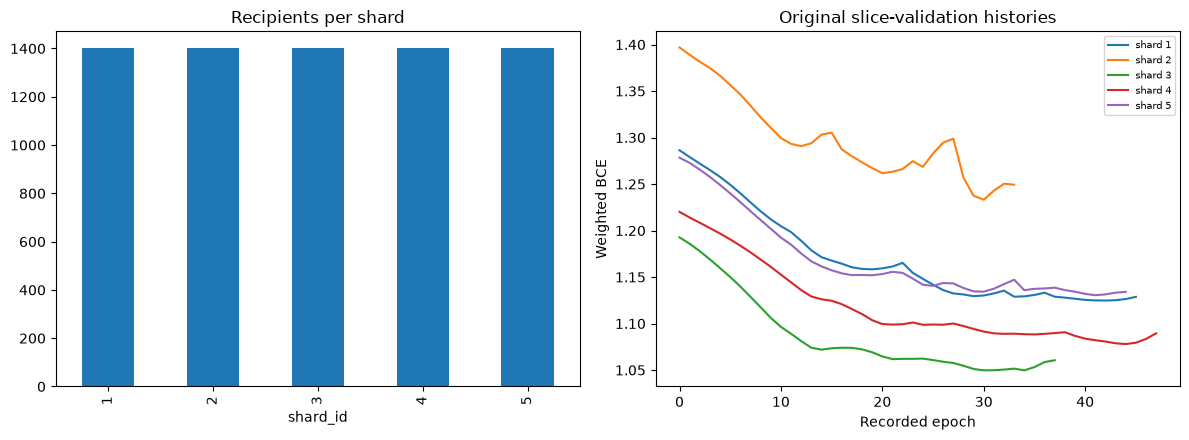

In [68]:
# Keep shard and slice operations explicit so SISA provenance remains auditable.
fig,axes=plt.subplots(1,2,figsize=(12,4.5))
shard_summary.plot.bar(x="shard_id",y="recipients",ax=axes[0],legend=False,title="Recipients per shard")
for shard_id in range(1,N_SHARDS+1):
    part=original_training_history.loc[original_training_history["shard_id"].eq(shard_id)]
    axes[1].plot(np.arange(len(part)),part["validation_weighted_bce"],label=f"shard {shard_id}")
axes[1].set(title="Original slice-validation histories",xlabel="Recorded epoch",ylabel="Weighted BCE")
axes[1].legend(fontsize=7)
fig.tight_layout()
fig.savefig(FIGURE_DIR/"sisa_structure_and_training.png",dpi=160,bbox_inches="tight")
plt.show()

The executed result matched the preflight: Policy-Aware SISA affected **9 scenario-shards**, reused **16 final shard models** and replayed **36 stages**, compared with 25 affected scenario-shards and 125 replay stages for standard hash-based SISA.

These savings come from aligning the assignment with known policy membership. They do not show that unknown future requests would be similarly local.

In [69]:
affected_total = int(scenario_ensemble_manifest_summary["affected_shards"].sum())
reused_total = int(scenario_ensemble_manifest_summary["reused_shards"].sum())
replayed_total = int(scenario_shard_impact["replayed_slice_stages"].sum())

# 7. Evaluate retained utility and forgetting

The threshold and individual utility definitions match the main method notebooks. Each scenario uses only its retained test records.

In [70]:
# Keep threshold 0.62 fixed for retained-test comparisons.
def binary_metrics(y, p, threshold=THRESHOLD):
    pred = (p >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0, 1]).ravel()
    return {"n": len(y), "positive_count": int(y.sum()), "prevalence": float(y.mean()), "threshold": threshold,
        "pr_auc": average_precision_score(y, p), "auroc": roc_auc_score(y, p),
        "balanced_accuracy": balanced_accuracy_score(y, pred), "f1": f1_score(y, pred, zero_division=0),
        "binary_cross_entropy": log_loss(y, p, labels=[0, 1]),
        "precision": precision_score(y, pred, zero_division=0), "recall": recall_score(y, pred, zero_division=0),
        "specificity": tn / (tn + fp), "accuracy": accuracy_score(y, pred),
        "positive_prediction_rate": float(pred.mean()), "true_negative": int(tn), "false_positive": int(fp),
        "false_negative": int(fn), "true_positive": int(tp)}

test_prediction_rows, policy_metric_rows = [], []


In [71]:
# Aggregate fixed shard outputs to recover the established ensemble prediction.
for scenario in SCENARIOS:
    frame = scenario_frames[scenario]["retained_test"].reset_index(drop=True)
    matrix = preprocessor.transform(frame[features]).astype("float32")
    y = frame[target].to_numpy()
    original = aggregate_models(original_models, matrix)
    updated = scenario_probabilities[scenario]["retained_test"]
    test_prediction_rows.append(pd.DataFrame({"scenario": scenario, "evaluation_row": np.arange(len(frame)),
        "assessment_id": frame["assessment_id"], "true_target": y,
        "policy_original_sisa_probability": original, "policy_aware_sisa_probability": updated,
        "policy_original_sisa_prediction": (original >= THRESHOLD).astype(int),
        "policy_aware_sisa_prediction": (updated >= THRESHOLD).astype(int)}))
    for method, probability in [("policy_original_sisa", original), ("policy_aware_sisa", updated)]:
        policy_metric_rows.append({"scenario": scenario, "model": method, **binary_metrics(y, probability)})
retained_test_predictions = pd.concat(test_prediction_rows, ignore_index=True)
policy_metrics = pd.DataFrame(policy_metric_rows)

Composite Model Utility uses `bce_quality = exp(-binary_cross_entropy)` and the unchanged safeguarded harmonic mean of PR-AUC, AUROC, balanced accuracy, F1 and BCE quality.

In [72]:
# Compare retained utility on the same scenario-specific test rows.
reference_metrics = gradient_utility_reference.copy()
metric_columns = list(policy_metrics.columns)
reference_metrics = reference_metrics[metric_columns]
hashed_metrics = hashed_utility.loc[hashed_utility["model"].eq("updated_sisa"), metric_columns].copy()
hashed_metrics["model"] = "hashed_sisa"
utility_metrics = pd.concat([reference_metrics, hashed_metrics, policy_metrics], ignore_index=True)
utility_metrics["bce_quality"] = np.exp(-utility_metrics["binary_cross_entropy"])
components = ["pr_auc", "auroc", "balanced_accuracy", "f1", "bce_quality"]
def harmonic(values, epsilon=1e-12):
    values = np.asarray(values, dtype=float)
    return float(len(values) / np.sum(1 / np.maximum(values, epsilon)))
utility_metrics["composite_model_utility"] = utility_metrics[components].apply(harmonic, axis=1)
composite_model_utility = utility_metrics[["scenario", "model", *components, "composite_model_utility"]]
assert np.allclose(composite_model_utility["composite_model_utility"],
                   composite_model_utility[components].apply(harmonic, axis=1), atol=1e-12, rtol=1e-12)

Baseline, full retraining, fine-tuning, gradient ascent, standard hash-based SISA and both policy-aware ensembles use aligned retained-test rows. Threshold `0.62` is unchanged.

In [73]:
# Measure utility changes without feeding them back into assignment.
wide = utility_metrics.pivot(index="scenario", columns="model")
delta_rows = []
delta_metrics = ["pr_auc", "auroc", "balanced_accuracy", "f1", "binary_cross_entropy",
                 "bce_quality", "composite_model_utility"]
for scenario in SCENARIOS:
    row = {"scenario": scenario}
    for metric in delta_metrics:
        updated = wide.loc[scenario, (metric, "policy_aware_sisa")]
        for reference in ["baseline", "full_retraining", "fine_tuning", "gradient_ascent",
                          "hashed_sisa", "policy_original_sisa"]:
            row[f"policy_aware_minus_{reference}_{metric}"] = updated - wide.loc[scenario, (metric, reference)]
    delta_rows.append(row)
utility_deltas = pd.DataFrame(delta_rows)
display(utility_metrics[["scenario", "model", *delta_metrics]])

,scenario,model,pr_auc,auroc,balanced_accuracy,f1,binary_cross_entropy,bce_quality,composite_model_utility
0,recipient_withdrawal,baseline,0.169267,0.731534,0.630478,0.244288,0.574755,0.562843,0.339417
1,donor_withdrawal,baseline,0.168604,0.731754,0.630475,0.244170,0.574600,0.562930,0.338853
2,hospital_removal,baseline,0.173596,0.739196,0.636655,0.252029,0.573226,0.563704,0.346601
3,invalid_consent,baseline,0.163900,0.735045,0.628857,0.237052,0.559673,0.571396,0.332878
4,retention_expiry,baseline,0.167302,0.744495,0.634281,0.252886,0.540615,0.582390,0.343208
5,recipient_withdrawal,full_retraining,0.177118,0.734572,0.628800,0.234677,0.590813,0.553877,0.340965
6,donor_withdrawal,full_retraining,0.173580,0.731609,0.633887,0.236778,0.599383,0.549150,0.338987
7,hospital_removal,full_retraining,0.176205,0.743964,0.641917,0.249229,0.590414,0.554098,0.347360
8,invalid_consent,full_retraining,0.167787,0.735362,0.637605,0.229071,0.595136,0.551488,0.331853
9,retention_expiry,full_retraining,0.162155,0.741491,0.627631,0.227008,0.585620,0.556761,0.326582


Utility is shown alongside affected shards and replay stages so structural and predictive outcomes remain separate.

In [74]:
# Replay only the affected shard suffix while preserving the frozen assignment.
scenario_structure = scenario_ensemble_manifest_summary.merge(
    scenario_shard_impact.groupby("scenario")["replayed_slice_stages"].sum().reset_index(), on="scenario")
utility_structure = composite_model_utility.loc[
    composite_model_utility["model"].eq("policy_aware_sisa")].merge(scenario_structure, on="scenario")
display(utility_structure)

,scenario,model,pr_auc,auroc,balanced_accuracy,f1,bce_quality,composite_model_utility,affected_shards,reused_shards,manifest_model_count,replayed_slice_stages
0,recipient_withdrawal,policy_aware_sisa,0.162725,0.714893,0.616265,0.230460,0.548182,0.326154,1,4,5,1
1,donor_withdrawal,policy_aware_sisa,0.163635,0.716148,0.621791,0.232270,0.542762,0.327577,1,4,5,2
2,hospital_removal,policy_aware_sisa,0.165568,0.721753,0.627744,0.236878,0.541409,0.331412,1,4,5,5
3,invalid_consent,policy_aware_sisa,0.159226,0.718840,0.619216,0.214805,0.536748,0.316358,3,2,5,14
4,retention_expiry,policy_aware_sisa,0.156509,0.725438,0.635487,0.232151,0.538952,0.322487,3,2,5,14


Mean Composite Model Utility remained broadly similar: approximately **0.32480** for Policy-Aware SISA and **0.32212** for standard hash-based SISA. The small difference should not be interpreted as a substantial utility improvement.

In [75]:
policy_utility = utility_metrics.loc[utility_metrics["model"].eq("policy_aware_sisa")].set_index("scenario")
hashed_utility_comparison = utility_metrics.loc[utility_metrics["model"].eq("hashed_sisa")].set_index("scenario")
utility_change = policy_utility["composite_model_utility"] - hashed_utility_comparison["composite_model_utility"]

Forgetting is evaluated on the unchanged training-forget records. Every SISA probability averages five constituent models, and all reference predictions are aligned by record.

In [76]:
# Align all methods on identical training-forget records.
def record_bce(y, p):
    p = np.clip(np.asarray(p, dtype=np.float64), 1e-15, 1 - 1e-15)
    y = np.asarray(y, dtype=np.float64)
    return -(y * np.log(p) + (1 - y) * np.log(1 - p))

forget_frames = []


In [77]:
# Aggregate fixed shard outputs to recover the established ensemble prediction.
for scenario in SCENARIOS:
    frame = scenario_frames[scenario]["training_forget"].reset_index(drop=True)
    matrix = preprocessor.transform(frame[features]).astype("float32")
    y = frame[target].to_numpy()
    ref = gradient_forget.loc[gradient_forget["scenario"].eq(scenario)].sort_values("evaluation_row").reset_index(drop=True)
    hashed = hashed_forget.loc[hashed_forget["scenario"].eq(scenario)].sort_values("evaluation_row").reset_index(drop=True)
    assert list(frame["assessment_id"]) == list(hashed["assessment_id"])
    probabilities = {method: ref[f"{method}_probability"].to_numpy(dtype=np.float64)
        for method in ["baseline", "full_retraining", "fine_tuning", "gradient_ascent"]}
    probabilities["hashed_sisa"] = hashed["updated_sisa_probability"].to_numpy(dtype=np.float64)
    probabilities["policy_original_sisa"] = aggregate_models(original_models, matrix)
    probabilities["policy_aware_sisa"] = scenario_probabilities[scenario]["training_forget"]
    output = pd.DataFrame({"scenario": scenario, "evaluation_row": np.arange(len(frame)),
                           "assessment_id": frame["assessment_id"], "true_target": y})
    for method, probability in probabilities.items():
        output[f"{method}_probability"] = probability
        output[f"{method}_prediction"] = (probability >= THRESHOLD).astype(int)
        output[f"{method}_per_record_bce"] = record_bce(y, probability)
    forget_frames.append(output)


In [78]:
forget_set_predictions = pd.concat(forget_frames, ignore_index=True)

The established binary Truth-Ratio definition and epsilon are reused unchanged.

In [79]:
# Truth Ratio summarises behaviour on forgotten records.
truth_frames=[]
for method in ["baseline", "full_retraining", "fine_tuning", "gradient_ascent", "hashed_sisa",
               "policy_original_sisa", "policy_aware_sisa"]:
    probability=forget_set_predictions[f"{method}_probability"].to_numpy(dtype=np.float64)
    y=forget_set_predictions["true_target"].to_numpy(dtype=np.int64)
    p_true=np.where(y==1,probability,1-probability)
    p_incorrect=1-p_true
    ratio=(p_incorrect+EPSILON)/(p_true+EPSILON)
    truth_frames.append(pd.DataFrame({"scenario":forget_set_predictions["scenario"],
        "evaluation_row":forget_set_predictions["evaluation_row"],"true_target":y,"model":method,
        "p_true":p_true,"p_incorrect":p_incorrect,"truth_ratio":ratio,"epsilon":EPSILON}))
truth_ratio_values=pd.concat(truth_frames,ignore_index=True)
truth_ratio_summary=truth_ratio_values.groupby(["scenario","model"])["truth_ratio"].agg(
    count="count",mean="mean",median="median",minimum="min",maximum="max",
    q1=lambda x:x.quantile(.25),q3=lambda x:x.quantile(.75)).reset_index()


In [80]:
truth_ratio_summary["interquartile_range"]=truth_ratio_summary["q3"]-truth_ratio_summary["q1"]
display(truth_ratio_summary)

,scenario,model,count,mean,median,minimum,maximum,q1,q3,interquartile_range
0,donor_withdrawal,baseline,1992,0.979881,0.906640,3.574875e-09,6.985770,0.390317,1.388092,0.997774
1,donor_withdrawal,fine_tuning,1992,1.015556,0.917704,3.442744e-09,7.737382,0.381329,1.430981,1.049652
2,donor_withdrawal,full_retraining,1992,1.065314,0.963850,1.271374e-07,7.135536,0.417091,1.516182,1.099091
3,donor_withdrawal,gradient_ascent,1992,1.028508,0.947777,4.375604e-09,7.630473,0.412730,1.448481,1.035751
4,donor_withdrawal,hashed_sisa,1992,0.996856,0.803003,1.235684e-03,8.464731,0.366870,1.389050,1.022180
5,donor_withdrawal,policy_aware_sisa,1992,1.021579,0.836914,1.347573e-02,6.191684,0.420443,1.398231,0.977788
6,donor_withdrawal,policy_original_sisa,1992,1.012680,0.825026,1.215905e-02,6.175430,0.411729,1.386584,0.974856
7,hospital_removal,baseline,4314,0.935517,0.810691,1.652883e-09,8.626322,0.310622,1.343399,1.032777
8,hospital_removal,fine_tuning,4314,0.969649,0.823250,1.504561e-09,9.838072,0.309193,1.390201,1.081007
9,hospital_removal,full_retraining,4314,1.011090,0.882400,4.613736e-09,10.233602,0.308297,1.430740,1.122443


Two-sided KS tests compare Policy-Aware SISA with full retraining. A lower statistic means closer observed distributions, while the p-value depends on sample size and does not prove equivalence, erasure or privacy.

In [81]:
# Use full retraining as the behavioural forgetting reference.
quality_rows = []
for scenario in SCENARIOS:
    part = truth_ratio_values.loc[truth_ratio_values["scenario"].eq(scenario)]
    policy = part.loc[part["model"].eq("policy_aware_sisa"), "truth_ratio"]
    full = part.loc[part["model"].eq("full_retraining"), "truth_ratio"]
    result = ks_2samp(policy, full, alternative="two-sided", method="auto")
    quality_rows.append({"scenario": scenario, "forget_rows": len(policy),
        "tofu_style_forget_quality": float(result.pvalue), "ks_statistic": float(result.statistic)})
forget_quality_core = pd.DataFrame(quality_rows)
forgetting_comparison = forget_quality_core.merge(
    hashed_quality[["scenario", "ks_statistic", "tofu_style_forget_quality"]].rename(columns={
        "ks_statistic": "hashed_ks_statistic", "tofu_style_forget_quality": "hashed_ks_p_value"}), on="scenario")
forgetting_comparison = forgetting_comparison.rename(columns={
    "ks_statistic": "policy_aware_ks_statistic", "tofu_style_forget_quality": "policy_aware_ks_p_value"})
display(forgetting_comparison)

,scenario,forget_rows,policy_aware_ks_p_value,policy_aware_ks_statistic,hashed_ks_statistic,hashed_ks_p_value
0,recipient_withdrawal,426,2.283404e-08,0.206573,0.150235,1.301308e-04
1,donor_withdrawal,1992,6.934800e-28,0.177711,0.107430,1.994542e-10
2,hospital_removal,4314,2.182257e-78,0.203292,0.131896,4.133776e-33
3,invalid_consent,4148,2.167901e-14,0.087994,0.039778,2.819496e-03
4,retention_expiry,6262,2.133227e-65,0.154264,0.047748,1.255609e-06


Supporting comparisons include full retraining, original SISA, fine-tuning and gradient ascent.

In [82]:
# Retain supporting distances without replacing the KS comparison.
support = []
for scenario in SCENARIOS:
    part = forget_set_predictions.loc[forget_set_predictions["scenario"].eq(scenario)]
    policy = part["policy_aware_sisa_probability"]
    full = part["full_retraining_probability"]
    hashed = part["hashed_sisa_probability"]
    support.append({"scenario": scenario,
        "mean_absolute_probability_difference_from_full": np.mean(np.abs(policy - full)),
        "median_absolute_probability_difference_from_full": np.median(np.abs(policy - full)),
        "prediction_agreement_with_full": np.mean(part["policy_aware_sisa_prediction"] == part["full_retraining_prediction"]),
        "mean_absolute_loss_difference_from_full": np.mean(np.abs(part["policy_aware_sisa_per_record_bce"] - part["full_retraining_per_record_bce"])),
        "mean_probability_change_from_hashed_sisa": np.mean(policy - hashed),
        "prediction_changed_from_hashed_sisa_pct": 100 * np.mean(part["policy_aware_sisa_prediction"] != part["hashed_sisa_prediction"]),
        "mean_absolute_probability_difference_from_fine_tuning": np.mean(np.abs(policy - part["fine_tuning_probability"])),
        "mean_absolute_probability_difference_from_gradient_ascent": np.mean(np.abs(policy - part["gradient_ascent_probability"]))})


In [83]:
forget_quality = forget_quality_core.merge(pd.DataFrame(support), on="scenario")

KS statistic is the primary descriptive distance across scenarios and is shown with affected shards and replay stages.

In [84]:
forget_quality=forget_quality.merge(scenario_structure,on="scenario")
display(forget_quality[["scenario","forget_rows","ks_statistic","tofu_style_forget_quality",
                        "affected_shards","replayed_slice_stages"]])

,scenario,forget_rows,ks_statistic,tofu_style_forget_quality,affected_shards,replayed_slice_stages
0,recipient_withdrawal,426,0.206573,2.283404e-08,1,1
1,donor_withdrawal,1992,0.177711,6.934800e-28,1,2
2,hospital_removal,4314,0.203292,2.182257e-78,1,5
3,invalid_consent,4148,0.087994,2.167901e-14,3,14
4,retention_expiry,6262,0.154264,2.133227e-65,3,14


Mean Truth-Ratio KS was approximately **0.1660** for Policy-Aware SISA and **0.1505** for standard hash-based SISA. Structural localisation therefore did not improve average behavioural similarity to full retraining.

SISA is a five-model ensemble whereas full retraining is a monolithic MLP, so the comparison also contains an architecture difference.

In [85]:
detectable = int(forget_quality["tofu_style_forget_quality"].lt(.05).sum())
mean_policy_ks = forget_quality["ks_statistic"].mean()
mean_hashed_ks = hashed_quality["ks_statistic"].mean()

# 8. Structural efficiency and runtime

Initial SISA preparation is separated from selective replay. Runtime is compared descriptively with full retraining, fine-tuning, gradient ascent and standard SISA.

In [86]:
# Compare wall-clock time beside affected shards and replay stages.
efficiency = deletion_time_summary.merge(
    hashed_efficiency[["scenario", "selective_retraining_seconds"]].rename(
        columns={"selective_retraining_seconds": "hashed_sisa_seconds"}), on="scenario").merge(
    full_training[["scenario", "training_seconds"]].rename(columns={"training_seconds": "full_retraining_seconds"}), on="scenario").merge(
    fine_training[["scenario", "training_seconds"]].rename(columns={"training_seconds": "fine_tuning_seconds"}), on="scenario").merge(
    gradient_training[["scenario", "training_seconds"]].rename(columns={"training_seconds": "gradient_ascent_seconds"}), on="scenario").merge(
    scenario_ensemble_manifest_summary[["scenario", "affected_shards", "reused_shards"]], on="scenario").merge(
    scenario_shard_impact.groupby("scenario")["replayed_slice_stages"].sum().reset_index(), on="scenario")
for method in ["hashed_sisa", "full_retraining", "fine_tuning", "gradient_ascent"]:
    efficiency[f"speed_up_vs_{method}"] = efficiency[f"{method}_seconds"] / efficiency["policy_aware_sequential_seconds"]
    efficiency[f"time_reduction_pct_vs_{method}"] = 100 * (efficiency[f"{method}_seconds"] -
        efficiency["policy_aware_sequential_seconds"]) / efficiency[f"{method}_seconds"]
display(efficiency)

,scenario,policy_aware_sequential_seconds,hashed_sisa_seconds,full_retraining_seconds,fine_tuning_seconds,gradient_ascent_seconds,affected_shards,reused_shards,replayed_slice_stages,speed_up_vs_hashed_sisa,time_reduction_pct_vs_hashed_sisa,speed_up_vs_full_retraining,time_reduction_pct_vs_full_retraining,speed_up_vs_fine_tuning,time_reduction_pct_vs_fine_tuning,speed_up_vs_gradient_ascent,time_reduction_pct_vs_gradient_ascent
0,recipient_withdrawal,0.061654,3.638856,3.923029,0.961513,0.082731,1,4,1,59.020765,98.305681,63.629922,98.428412,15.595347,93.587831,1.341856,25.476369
1,donor_withdrawal,0.055830,3.631015,3.450068,1.012794,0.164424,1,4,2,65.036700,98.462407,61.795674,98.381764,18.140591,94.487501,2.945067,66.044916
2,hospital_removal,0.269600,3.454197,3.847863,0.908232,0.308786,1,4,5,12.812323,92.195014,14.272513,92.993526,3.368820,70.316017,1.145352,12.690608
3,invalid_consent,1.009437,3.449524,3.528170,1.373795,0.370443,3,2,14,3.417274,70.736907,3.495184,71.389206,1.360952,26.522002,0.366980,-172.494644
4,retention_expiry,0.945753,3.498488,3.111061,3.194244,0.454323,3,2,14,3.699155,72.966799,3.289505,69.600292,3.377460,70.391952,0.480383,-108.167439


The table above reports the measured runtime for every scenario alongside affected shards and replay stages. Structural replay work genuinely fell, but wall-clock time remains machine-specific and is influenced by shard sizes, cumulative state, early stopping and normal execution variation.

The utility-versus-KS plot keeps the three outcome dimensions separate. Lower KS is better descriptively; p-value is not used as the cross-scenario axis.

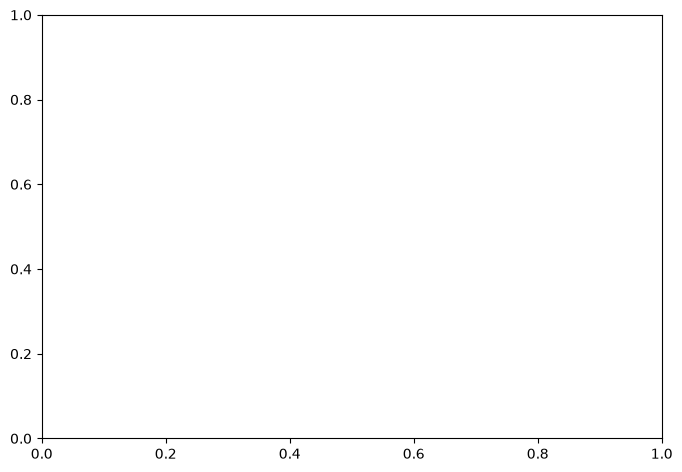

In [87]:
# Plot retained utility and forgetting as separate outcomes.
trade = []
for method, quality in [("policy_aware_sisa", forget_quality_core),
                        ("fine_tuning", fine_quality), ("gradient_ascent", gradient_quality)]:
    utility = composite_model_utility.loc[composite_model_utility["model"].eq(method),
                                           ["scenario", "composite_model_utility"]]
    trade.append(utility.merge(quality[["scenario", "ks_statistic"]], on="scenario").assign(method=method))
hashed_trade = composite_model_utility.loc[composite_model_utility["model"].eq("hashed_sisa"),
                                            ["scenario", "composite_model_utility"]].merge(
    hashed_quality[["scenario", "ks_statistic"]], on="scenario").assign(method="hashed_sisa")
trade_plot = pd.concat([*trade, hashed_trade], ignore_index=True)
fig, ax = plt.subplots(figsize=(8, 5.5))


In [88]:
# Keep shard and slice operations explicit so SISA provenance remains auditable.
for method, marker in [("policy_aware_sisa", "o"), ("hashed_sisa", "D"),
                       ("fine_tuning", "s"), ("gradient_ascent", "^")]:
    part = trade_plot.loc[trade_plot["method"].eq(method)]
    ax.scatter(part["composite_model_utility"], part["ks_statistic"], marker=marker, s=70,
               label=method.replace("_", " "))
ax.set(xlabel="Composite Model Utility", ylabel="KS statistic (lower is better)",
       title="Utility and forget distance")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / "utility_vs_forget_distance.png", dpi=160, bbox_inches="tight")
plt.show()

# 9. Compare SISA partitioning strategies

The combined comparison reports utility, forgetting distance, replay structure and measured cost as separate quantities.

In [89]:
policy_composite = composite_model_utility.loc[composite_model_utility["model"].eq("policy_aware_sisa")]
combined_tradeoff = policy_composite.merge(forget_quality, on="scenario").merge(efficiency, on="scenario")
display(combined_tradeoff)

,scenario,model,pr_auc,auroc,balanced_accuracy,f1,bce_quality,composite_model_utility,forget_rows,tofu_style_forget_quality,...,reused_shards_y,replayed_slice_stages_y,speed_up_vs_hashed_sisa,time_reduction_pct_vs_hashed_sisa,speed_up_vs_full_retraining,time_reduction_pct_vs_full_retraining,speed_up_vs_fine_tuning,time_reduction_pct_vs_fine_tuning,speed_up_vs_gradient_ascent,time_reduction_pct_vs_gradient_ascent
0,recipient_withdrawal,policy_aware_sisa,0.162725,0.714893,0.616265,0.230460,0.548182,0.326154,426,2.283404e-08,...,4,1,59.020765,98.305681,63.629922,98.428412,15.595347,93.587831,1.341856,25.476369
1,donor_withdrawal,policy_aware_sisa,0.163635,0.716148,0.621791,0.232270,0.542762,0.327577,1992,6.934800e-28,...,4,2,65.036700,98.462407,61.795674,98.381764,18.140591,94.487501,2.945067,66.044916
2,hospital_removal,policy_aware_sisa,0.165568,0.721753,0.627744,0.236878,0.541409,0.331412,4314,2.182257e-78,...,4,5,12.812323,92.195014,14.272513,92.993526,3.368820,70.316017,1.145352,12.690608
3,invalid_consent,policy_aware_sisa,0.159226,0.718840,0.619216,0.214805,0.536748,0.316358,4148,2.167901e-14,...,2,14,3.417274,70.736907,3.495184,71.389206,1.360952,26.522002,0.366980,-172.494644
4,retention_expiry,policy_aware_sisa,0.156509,0.725438,0.635487,0.232151,0.538952,0.322487,6262,2.133227e-65,...,2,14,3.699155,72.966799,3.289505,69.600292,3.377460,70.391952,0.480383,-108.167439


Policy-aware partitioning substantially reduced replay work, while retained utility changed only slightly and average Truth-Ratio similarity did not improve. This is evidence of **configuration sensitivity**, not universal superiority.

Measured runtime should be read alongside affected shards and replay stages. The policy-aware configuration has genuine structural savings, but its single-run wall-clock values do not support a general speed claim.

# 10. Verification, findings and limitations

The saved checkpoints, manifests, result tables and audit reports remain unchanged. Verification below protects assignment reproduction, cumulative state, replay, forgotten-row exclusion, model reuse, probability reproduction, utility, Truth Ratio, KS and protected inputs.

In [90]:
# Confirm all checkpoints and manifests have the expected SISA structure.
assert len(original_checkpoint_paths)==25
assert all("model_state_dict" in torch.load(path,weights_only=False) and
           "optimizer_state_dict" in torch.load(path,weights_only=False) for path in original_checkpoint_paths)
assert all(len(manifest["models"])==5 and all(not Path(item["model_path"]).is_absolute() for item in manifest["models"])
           for manifest in scenario_manifests.values())

Per-shard probability arrays are represented by canonical float64 fingerprints. The detailed assertions remain because they protect the experimental interpretation even though their presentation is compact.

In [91]:
# Preserve every table needed for assignment and result reproduction.
outputs = {"shard_summary.csv": shard_summary, "slice_summary.csv": slice_summary,
    "shard_composition.csv": shard_composition, "assignment_validation.csv": assignment_validation,
    "slice_optimisation.csv": slice_optimisation, "locality_comparison.csv": locality_comparison,
    "structural_preflight_report.csv": preflight_checks, "original_training_history.csv": original_training_history,
    "original_training_summary.csv": original_training_summary,
    "original_ensemble_predictions.csv": original_ensemble_predictions,
    "scenario_shard_impact.csv": scenario_shard_impact,
    "scenario_shard_operations.csv": scenario_shard_operations,
    "selective_retraining_history.csv": selective_retraining_history,
    "selective_retraining_summary.csv": selective_retraining_summary,
    "scenario_ensemble_manifest_summary.csv": scenario_ensemble_manifest_summary,
    "replay_seed_audit.csv": replay_seed_audit, "reused_shard_verification.csv": reused_shard_verification,
    "retained_test_predictions.csv": retained_test_predictions, "utility_metrics.csv": utility_metrics,
    "composite_model_utility.csv": composite_model_utility, "utility_deltas.csv": utility_deltas,
    "forget_set_predictions.csv": forget_set_predictions, "truth_ratio_values.csv": truth_ratio_values,
    "truth_ratio_summary.csv": truth_ratio_summary, "forget_quality.csv": forget_quality,
    "forgetting_comparison.csv": forgetting_comparison, "efficiency_comparison.csv": efficiency,
    "combined_tradeoff.csv": combined_tradeoff,
    "shard_probability_fingerprints.csv": shard_probability_fingerprints}


In [92]:
# Aggregate fixed shard outputs to recover the established ensemble prediction.
for name, frame in outputs.items(): frame.to_csv(RESULT_DIR / name, index=False, float_format="%.17g")
assignment_design_report = {"experiment": "Policy-aware SISA configuration sensitivity experiment",
    "optimistic_known_policy_design": True, "allowed_inputs": ["training recipient IDs", "donor IDs",
    "five predefined training-forget membership masks", "seed 42"],
    "excluded_inputs": [target, *features, "predictions", "test metrics", "KS", "runtime"],
    "lexicographic_optimisation": optimisation_report, "canonical_policy_footprint":
    {key: sorted(value) for key, value in POLICY_FOOTPRINT.items()},
    "maximum_shard_deviation_pct": max_shard_deviation_pct, "donor_components_crossing_shards": int(donor_crossings)}
_ = (RESULT_DIR / "assignment_design_report.json").write_text(json.dumps(assignment_design_report, indent=2) + "\n")
_ = (RESULT_DIR / "configuration.json").write_text(json.dumps(original_configuration, indent=2) + "\n")

In [93]:
# Confirm the saved assignment matches the in-memory mapping.
saved_assignment=pd.read_csv(ASSIGNMENT_PATH)
assignment_readback_pass=saved_assignment.equals(assignment)
assert assignment_readback_pass

In [94]:
# Reproduce the deterministic policy-aware assignment.
reproduced_footprint, reproduced_optimisation = solve_policy_footprint(donor_components)
assert reproduced_optimisation == optimisation_report
reproduced_shards, reproduced_loads = assign_component_shards(donor_components, POLICY_FOOTPRINT)
reproduced_slices, _ = assign_component_slices(donor_components, reproduced_shards, policy_recipient_counts)
reproduced = assignment_inputs[["recipient_id", "donor_id"]].copy()
reproduced["shard_id"] = reproduced["donor_id"].map(reproduced_shards)
reproduced["slice_id"] = reproduced["donor_id"].map(reproduced_slices)
reproduced = reproduced.sort_values("recipient_id").reset_index(drop=True)
assignment_reproduction_pass = saved_assignment.equals(reproduced)
assignment_report = {"status": "passed" if assignment_reproduction_pass else "failed",
    "rows": len(saved_assignment), "sha256": sha256_file(ASSIGNMENT_PATH),
    "algorithm": "policy-mask footprint optimisation plus deterministic donor-component bin packing"}
_ = (RESULT_DIR / "assignment_reproduction_report.json").write_text(json.dumps(assignment_report, indent=2) + "\n")
assert assignment_reproduction_pass

In [95]:
# Confirm every donor component occupies one shard and slice.
coverage_pass=bool(assignment_validation["pass"].all() and len(shard_summary)==5 and len(slice_summary)==25)
assert coverage_pass

In [96]:
# Reload every original checkpoint with its optimizer state.
original_checkpoint_reload_pass=True
for path in original_checkpoint_paths:
    checkpoint=torch.load(path,weights_only=False)
    model=BaselineMLP()
    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer=torch.optim.AdamW(model.parameters(),lr=LEARNING_RATE,weight_decay=WEIGHT_DECAY)
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    original_checkpoint_reload_pass &= checkpoint["architecture"]==[24,64,32,1]
assert original_checkpoint_reload_pass

In [97]:
# Confirm each scenario manifest resolves five constituent models.
manifest_checks=[]
for scenario,manifest in scenario_manifests.items():
    paths=[ROOT/item["model_path"] for item in manifest["models"]]
    manifest_checks.append({"scenario":scenario,"five_models":len(paths)==5,
                            "all_relative":all(not Path(item["model_path"]).is_absolute() for item in manifest["models"]),
                            "all_exist":all(path.is_file() for path in paths)})
manifest_checks=pd.DataFrame(manifest_checks)
manifest_pass=bool(manifest_checks.drop(columns="scenario").to_numpy().all())
assert manifest_pass

In [98]:
# Confirm forgotten rows are excluded and reused models stay byte-identical.
forgotten_exclusion_pass = bool(forgotten_exclusion["pass"].all())
assert forgotten_exclusion_pass and reused_shards_pass

In [99]:
# Reload manifest models independently from saved paths.
def load_manifest_models(manifest):
    models = []
    for item in manifest["models"]:
        checkpoint = torch.load(ROOT / item["model_path"], weights_only=False)
        model = BaselineMLP()
        model.load_state_dict(checkpoint["model_state_dict"])
        optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
        model.eval()
        models.append(model)
    return models

reloaded_models = {scenario: load_manifest_models(manifest)
                   for scenario, manifest in scenario_manifests.items()}


In [100]:
# Keep shard and slice operations explicit so SISA provenance remains auditable.
model_reload_verification = pd.DataFrame([
    {"scenario": scenario, "model_count": len(models), "all_five_models_loaded": len(models) == 5}
    for scenario, models in reloaded_models.items()
])
model_reload_verification.to_csv(RESULT_DIR / "model_reload_verification.csv", index=False)
model_reload_pass = bool(model_reload_verification["all_five_models_loaded"].all())
assert model_reload_pass

In [101]:
# Reproduce each shard probability fingerprint.
fingerprint_rows=[]
for scenario in SCENARIOS:
    for partition in ["retained_validation","retained_test","training_forget"]:
        frame=scenario_frames[scenario][partition]
        matrix=preprocessor.transform(frame[features]).astype("float32")
        aggregate_models(reloaded_models[scenario],matrix,fingerprint_rows,scenario,partition)
reproduced_fingerprints=pd.DataFrame(fingerprint_rows)
fingerprint_pass=reproduced_fingerprints.equals(shard_probability_fingerprints)
assert fingerprint_pass

In [102]:
# Confirm reloaded ensembles reproduce saved probabilities.
ensemble_rows = []
for scenario in SCENARIOS:
    for partition, column in [("retained_test", "policy_aware_sisa_probability"),
                              ("training_forget", "policy_aware_sisa_probability")]:
        frame = scenario_frames[scenario][partition]
        matrix = preprocessor.transform(frame[features]).astype("float32")
        reproduced_probability = aggregate_models(reloaded_models[scenario], matrix)
        saved_frame = retained_test_predictions if partition == "retained_test" else forget_set_predictions
        saved_probability = saved_frame.loc[saved_frame["scenario"].eq(scenario), column].to_numpy()
        ensemble_rows.append({"scenario": scenario, "partition": partition,
            "maximum_absolute_difference": float(np.max(np.abs(reproduced_probability - saved_probability))),
            "pass": np.allclose(reproduced_probability, saved_probability, atol=1e-8, rtol=1e-8)})
ensemble_probability_reproduction = pd.DataFrame(ensemble_rows)


In [103]:
# Keep shard and slice operations explicit so SISA provenance remains auditable.
ensemble_probability_reproduction.to_csv(
    RESULT_DIR / "ensemble_probability_reproduction.csv", index=False, float_format="%.17g"
)
ensemble_pass = bool(ensemble_probability_reproduction["pass"].all())
assert ensemble_pass

In [104]:
# Recalculate utility from saved predictions.
saved_predictions = pd.read_csv(RESULT_DIR / "retained_test_predictions.csv")
saved_utility = pd.read_csv(RESULT_DIR / "utility_metrics.csv")
saved_composite = pd.read_csv(RESULT_DIR / "composite_model_utility.csv")
metric_names = ["n", "positive_count", "prevalence", "threshold", "pr_auc", "auroc",
    "balanced_accuracy", "f1", "binary_cross_entropy", "precision", "recall", "specificity",
    "accuracy", "positive_prediction_rate", "true_negative", "false_positive", "false_negative", "true_positive"]
reproduction_rows = []


In [105]:
# Aggregate fixed shard outputs to recover the established ensemble prediction.
for scenario in SCENARIOS:
    predictions = saved_predictions.loc[saved_predictions["scenario"].eq(scenario)]
    for model, probability_column in [("policy_original_sisa", "policy_original_sisa_probability"),
                                      ("policy_aware_sisa", "policy_aware_sisa_probability")]:
        calculated = binary_metrics(
            predictions["true_target"].to_numpy(), predictions[probability_column].to_numpy()
        )
        saved_row = saved_utility.loc[
            saved_utility["scenario"].eq(scenario) & saved_utility["model"].eq(model)
        ].iloc[0]
        for metric in metric_names:
            expected, actual = float(saved_row[metric]), float(calculated[metric])
            tolerance = 0.0 if metric in {"n", "positive_count", "true_negative", "false_positive",
                                           "false_negative", "true_positive"} else 1e-8
            reproduction_rows.append({"scenario": scenario, "model": model, "metric": metric,
                "saved_value": expected, "recalculated_value": actual, "absolute_difference": abs(expected - actual),
                "tolerance": tolerance, "pass": bool(np.isclose(expected, actual, atol=tolerance, rtol=0))})

In [106]:
# Recalculate each saved utility value from persisted probabilities.
for scenario in SCENARIOS:
    for model in ["policy_original_sisa", "policy_aware_sisa"]:
        saved_row = saved_utility.loc[
            saved_utility["scenario"].eq(scenario) & saved_utility["model"].eq(model)
        ].iloc[0]
        saved_composite_row = saved_composite.loc[
            saved_composite["scenario"].eq(scenario) & saved_composite["model"].eq(model)
        ].iloc[0]
        bce_quality = float(np.exp(-saved_row["binary_cross_entropy"]))
        composite = harmonic([saved_row["pr_auc"], saved_row["auroc"], saved_row["balanced_accuracy"],
                              saved_row["f1"], bce_quality])
        for metric, expected, actual in [
            ("bce_quality", saved_composite_row["bce_quality"], bce_quality),
            ("composite_model_utility", saved_composite_row["composite_model_utility"], composite),
        ]:
            reproduction_rows.append({"scenario": scenario, "model": model, "metric": metric,
                "saved_value": float(expected), "recalculated_value": float(actual),
                "absolute_difference": abs(float(expected) - float(actual)), "tolerance": 1e-8,
                "pass": bool(np.isclose(expected, actual, atol=1e-8, rtol=0))})


In [107]:
# Keep shard and slice operations explicit so SISA provenance remains auditable.
utility_metric_reproduction = pd.DataFrame(reproduction_rows)
utility_metric_reproduction.to_csv(
    RESULT_DIR / "utility_metric_reproduction.csv", index=False, float_format="%.17g"
)
base_metric_pass = bool(utility_metric_reproduction.loc[
    ~utility_metric_reproduction["metric"].isin(["bce_quality", "composite_model_utility"]), "pass"].all())
composite_utility_reproduction_pass = bool(utility_metric_reproduction.loc[
    utility_metric_reproduction["metric"].isin(["bce_quality", "composite_model_utility"]), "pass"].all())
utility_reproduction_pass = base_metric_pass and composite_utility_reproduction_pass
assert utility_reproduction_pass

In [108]:
# Reproduce Truth Ratio from persisted probability components.
saved_truth=pd.read_csv(RESULT_DIR/"truth_ratio_values.csv")
reproduced_ratio=(saved_truth["p_incorrect"]+saved_truth["epsilon"])/(saved_truth["p_true"]+saved_truth["epsilon"])
ratio_difference=np.abs(saved_truth["truth_ratio"]-reproduced_ratio)
truth_ratio_pass=bool(np.allclose(saved_truth["truth_ratio"],reproduced_ratio,atol=1e-8,rtol=0))
truth_ratio_diagnostic=pd.DataFrame([{"rows":len(saved_truth),"maximum_absolute_difference":float(ratio_difference.max()),
                                     "required_tolerance":1e-8,"pass":truth_ratio_pass}])
truth_ratio_diagnostic.to_csv(RESULT_DIR/"truth_ratio_reproduction_diagnostic.csv",index=False,float_format="%.17g")
assert truth_ratio_pass

In [109]:
# Reproduce KS statistics and p-values from saved ratios.
saved_quality=pd.read_csv(RESULT_DIR/"forget_quality.csv").set_index("scenario")
ks_pass=True
for scenario in SCENARIOS:
    part=saved_truth.loc[saved_truth["scenario"].eq(scenario)]
    result=ks_2samp(part.loc[part["model"].eq("policy_aware_sisa"),"truth_ratio"],
                    part.loc[part["model"].eq("full_retraining"),"truth_ratio"])
    ks_pass &= np.isclose(result.statistic,saved_quality.loc[scenario,"ks_statistic"],atol=1e-12,rtol=1e-12)
    ks_pass &= np.isclose(result.pvalue,saved_quality.loc[scenario,"tofu_style_forget_quality"],atol=1e-12,rtol=1e-12)
assert ks_pass

In [110]:
# Keep the baseline threshold and approved feature order unchanged.
threshold_feature_pass=THRESHOLD==.62 and features==baseline_config["classifier_features"] and direct_fields.isdisjoint(features)
assert threshold_feature_pass

In [111]:
# Confirm identifiers, assignments and targets remain outside model inputs.
leakage_fields = direct_fields | {target, "membership_type"}
target_absent_from_features = target not in features
leakage_pass = (leakage_fields.isdisjoint(features)
                and {"shard_id", "slice_id"}.isdisjoint(features)
                and target_absent_from_features)
assert target_absent_from_features and leakage_pass

In [112]:
# Confirm protected references and original checkpoints remain unchanged.
input_hashes_after = {path.relative_to(ROOT).as_posix(): sha256_file(path) for path in protected_paths}
protected_hash_pass = input_hashes_before == input_hashes_after
original_hashes_after = {path.name: sha256_file(path) for path in original_checkpoint_paths}
unchanged_original_shards_pass = original_checkpoint_hashes == original_hashes_after
artifact_integrity = {"protected_inputs_unchanged": protected_hash_pass,
    "original_policy_checkpoints_unchanged_after_replay": unchanged_original_shards_pass,
    "hashed_reference_sha256": input_hashes_after["docs/data_generation/sisa_historical_evidence/05_sisa_hashed_reference.ipynb"],
    "protected_file_count": len(input_hashes_before), "before": input_hashes_before, "after": input_hashes_after}
_ = (RESULT_DIR / "integrity_report.json").write_text(json.dumps(artifact_integrity, indent=2) + "\n")
reproducibility_report = {"status": "passed", "assignment_reproduced": assignment_reproduction_pass,
    "replay_seed_audit_pass": replay_seed_audit_pass, "probability_reproduction_pass": ensemble_pass,
    "utility_reproduction_pass": utility_reproduction_pass, "truth_ratio_reproduction_pass": truth_ratio_pass,
    "ks_reproduction_pass": bool(ks_pass), "reused_shards_byte_identical": reused_shards_pass,
    "protected_inputs_unchanged": protected_hash_pass, "network_requests": 0}
_ = (RESULT_DIR / "reproducibility_report.json").write_text(json.dumps(reproducibility_report, indent=2) + "\n")


In [113]:
assert protected_hash_pass and unchanged_original_shards_pass

In [114]:
# Require every isolated policy-aware artifact before completion.
required = [ASSIGNMENT_PATH, ORIGINAL_DIR / "ensemble_manifest.json", ORIGINAL_DIR / "configuration.json",
    RESULT_DIR / "assignment_design_report.json", RESULT_DIR / "assignment_reproduction_report.json",
    RESULT_DIR / "structural_preflight_report.csv", RESULT_DIR / "locality_comparison.csv",
    RESULT_DIR / "integrity_report.json", RESULT_DIR / "reproducibility_report.json",
    RESULT_DIR / "model_reload_verification.csv", RESULT_DIR / "ensemble_probability_reproduction.csv",
    RESULT_DIR / "truth_ratio_reproduction_diagnostic.csv", RESULT_DIR / "utility_metric_reproduction.csv",
    RESULT_DIR / "replay_seed_audit.csv", RESULT_DIR / "reused_shard_verification.csv",
    FIGURE_DIR / "sisa_structure_and_training.png", FIGURE_DIR / "utility_vs_forget_distance.png",
    RESULT_DIR / "run_summary.json", RESULT_DIR / "configuration.json"]
required += [RESULT_DIR / name for name in outputs]
required += original_checkpoint_paths
required += [UNLEARNED_DIR / scenario / name for scenario in SCENARIOS
             for name in ["ensemble_manifest.json", "configuration.json"]]
required_artifact_pass = all(path.is_file() for path in required)
assert required_artifact_pass

In [115]:
# Require all methodological and numerical checks to pass.
acceptance = pd.DataFrame([
    {"requirement": "Dependency and alignment gate", "pass": bool(artifact_checks["pass"].all())},
    {"requirement": "Zero-training structural preflight", "pass": preflight_pass},
    {"requirement": "Assignment readback and reproduction", "pass": assignment_readback_pass and assignment_reproduction_pass},
    {"requirement": "Shard/slice and donor-component coverage", "pass": coverage_pass and donor_crossings == 0},
    {"requirement": "Original checkpoints and manifests", "pass": original_checkpoint_reload_pass and manifest_pass},
    {"requirement": "Deterministic suffix replay seeds", "pass": replay_seed_audit_pass},
    {"requirement": "Forgotten-row exclusion and byte-identical reuse", "pass": forgotten_exclusion_pass and reused_shards_pass},
    {"requirement": "Model, fingerprint and ensemble reproduction", "pass": model_reload_pass and fingerprint_pass and ensemble_pass},
    {"requirement": "Saved utility and composite reproduction", "pass": utility_reproduction_pass},
    {"requirement": "Truth-ratio and KS reproduction", "pass": truth_ratio_pass and ks_pass},
    {"requirement": "Matching memberships and evaluation rows", "pass": bool(artifact_checks["pass"].all())},
    {"requirement": "Threshold, features and leakage", "pass": threshold_feature_pass and leakage_pass and target_absent_from_features},
    {"requirement": "Protected hashed evidence and original policy checkpoints", "pass": protected_hash_pass and unchanged_original_shards_pass},
    {"requirement": "Required isolated artifacts", "pass": required_artifact_pass},
])


In [116]:
acceptance["status"] = acceptance["pass"].map({True: "PASS", False: "FAIL"})
display(acceptance.drop(columns="pass"))
assert acceptance["pass"].all()

,requirement,status
0,Dependency and alignment gate,PASS
1,Zero-training structural preflight,PASS
2,Assignment readback and reproduction,PASS
3,Shard/slice and donor-component coverage,PASS
4,Original checkpoints and manifests,PASS
5,Deterministic suffix replay seeds,PASS
6,Forgotten-row exclusion and byte-identical reuse,PASS
7,"Model, fingerprint and ensemble reproduction",PASS
8,Saved utility and composite reproduction,PASS
9,Truth-ratio and KS reproduction,PASS


All final acceptance checks passed in the preserved execution. Assignment, checkpoints, manifests, forgotten-row exclusion, reused-shard hashes, predictions, utility, Truth Ratio, KS and protected-input hashes reconciled.

In [117]:
# Retain the maximum reload difference for the final run summary.
max_reload = ensemble_probability_reproduction["maximum_absolute_difference"].max()

**Findings and limitations**

This exploratory experiment deliberately used advance knowledge of exact predefined deletion-policy membership. That privileged information allowed the partition to concentrate known requests; it would not normally be available for unknown future deletion requests.

Policy-Aware SISA reduced affected scenario-shards from **25 to 9**, reduced replay stages from **125 to 36**, and allowed **16 final shard models** to be reused. Retained utility remained broadly similar to standard hash-based SISA, while average Truth-Ratio KS similarity to full retraining did not improve.

The result shows that SISA selective-retraining efficiency is sensitive to partition design. Better structural localisation did not automatically improve retained utility or behavioural forgetting similarity.

Policy-Aware SISA is an optimistic configuration-sensitivity experiment. Exact membership in the five predefined policies shaped shard and slice placement. Unknown, novel or distributed future requests may again affect every shard and early slice.

SISA remains a five-model ensemble while full retraining is a monolithic model, so KS differences cannot isolate deletion behaviour from architecture. A lower KS statistic or higher p-value is not proof of erasure. Runtime is hardware-dependent, the frozen preprocessor is not unlearned, and one split, seed and configuration cannot establish privacy, clinical validity or universal performance.

Standard hash-based SISA remains the primary SISA reference. Provider-aware SISA, where discussed, uses plausible provider provenance without exact future membership; Policy-Aware SISA goes further by using privileged policy membership and should remain separate in the dissertation discussion.

In [118]:
# Write completed status only after acceptance succeeds.
assert acceptance["pass"].all() and required_artifact_pass and protected_hash_pass


In [119]:
# Replay only the affected shard suffix while preserving the frozen assignment.
run_summary = {"status": "completed", "task": "Policy-aware SISA configuration sensitivity experiment",
    "seed": SEED, "threshold": THRESHOLD, "configuration": original_configuration,
    "preparation_seconds": preparation_seconds, "original_checkpoint_count": 25,
    "original_storage_bytes": original_storage_bytes, "updated_storage_bytes": updated_storage_bytes,
    "affected_shards": dict(zip(scenario_ensemble_manifest_summary["scenario"],
                                scenario_ensemble_manifest_summary["affected_shards"])),
    "reused_shards": dict(zip(scenario_ensemble_manifest_summary["scenario"],
                              scenario_ensemble_manifest_summary["reused_shards"])),
    "replayed_slice_stages": scenario_shard_impact.groupby("scenario")["replayed_slice_stages"].sum().to_dict(),
    "sequential_deletion_seconds": deletion_time.to_dict(), "parallel_runtime_measured": False,
    "replay_seed_audit_pass": replay_seed_audit_pass, "reused_shards_byte_identical": reused_shards_pass,
    "all_models_verified": model_reload_pass, "maximum_ensemble_probability_difference": float(max_reload),
    "utility_metrics_reproduced": base_metric_pass,
    "composite_utility_reproduced": composite_utility_reproduction_pass,
    "all_verification_checks_pass": True, "protected_inputs_unchanged": protected_hash_pass,
    "original_policy_checkpoints_unchanged": unchanged_original_shards_pass, "network_requests": 0}


In [120]:
_ = (RESULT_DIR / "run_summary.json").write_text(json.dumps(run_summary, indent=2) + "\n")

# Results

## 1. Utility by Deletion Scenario

| Scenario | Model | PR-AUC ↑ | Balanced Accuracy ↑ | BCE ↓ | F1 ↑ | AUROC ↑ | Composite Utility ↑ |
| --- | ---: | ---: | ---: | ---: | ---: | ---: | ---: |
| Recipient Withdrawal | Baseline | 0.1693 | 0.6305 | 0.5748 | 0.2443 | 0.7315 | 0.3394 |
| Recipient Withdrawal | Full Retraining | 0.1771 | 0.6288 | 0.5908 | 0.2347 | 0.7346 | 0.3410 |
| Recipient Withdrawal | Policy-Aware SISA | 0.1627 | 0.6163 | 0.6011 | 0.2305 | 0.7149 | 0.3262 |
| Donor Withdrawal | Baseline | 0.1686 | 0.6305 | 0.5746 | 0.2442 | 0.7318 | 0.3389 |
| Donor Withdrawal | Full Retraining | 0.1736 | 0.6339 | 0.5994 | 0.2368 | 0.7316 | 0.3390 |
| Donor Withdrawal | Policy-Aware SISA | 0.1636 | 0.6218 | 0.6111 | 0.2323 | 0.7161 | 0.3276 |
| Hospital Removal | Baseline | 0.1736 | 0.6367 | 0.5732 | 0.2520 | 0.7392 | 0.3466 |
| Hospital Removal | Full Retraining | 0.1762 | 0.6419 | 0.5904 | 0.2492 | 0.7440 | 0.3474 |
| Hospital Removal | Policy-Aware SISA | 0.1656 | 0.6277 | 0.6136 | 0.2369 | 0.7218 | 0.3314 |
| Invalid Consent | Baseline | 0.1639 | 0.6289 | 0.5597 | 0.2371 | 0.7350 | 0.3329 |
| Invalid Consent | Full Retraining | 0.1678 | 0.6376 | 0.5951 | 0.2291 | 0.7354 | 0.3319 |
| Invalid Consent | Policy-Aware SISA | 0.1592 | 0.6192 | 0.6222 | 0.2148 | 0.7188 | 0.3164 |
| Retention Expiry | Baseline | 0.1673 | 0.6343 | 0.5406 | 0.2529 | 0.7445 | 0.3432 |
| Retention Expiry | Full Retraining | 0.1622 | 0.6276 | 0.5856 | 0.2270 | 0.7415 | 0.3266 |
| Retention Expiry | Policy-Aware SISA | 0.1565 | 0.6355 | 0.6181 | 0.2322 | 0.7254 | 0.3225 |

Composite Utility is a supporting summary metric; individual utility metrics remain visible.

## 2. Forgetting

| Scenario | Training Forget Rows | KS Statistic ↓ | KS p-value | Mean TR: Policy-Aware SISA | Mean TR: Full Retraining |
| --- | ---: | ---: | ---: | ---: | ---: |
| Recipient Withdrawal | 426 | 0.2066 | 2.283e-08 | 0.9274 | 0.9515 |
| Donor Withdrawal | 1,992 | 0.1777 | 6.935e-28 | 1.0216 | 1.0653 |
| Hospital Removal | 4,314 | 0.2033 | 2.182e-78 | 1.0008 | 1.0111 |
| Invalid Consent | 4,148 | 0.0880 | 2.168e-14 | 1.3305 | 1.2611 |
| Retention Expiry | 6,262 | 0.1543 | 2.133e-65 | 1.6972 | 1.4427 |
| Mean | — | 0.1660 | Not averaged | 1.1955 | 1.1463 |

The KS statistic is the primary distribution-distance measure. Its p-value does not prove equivalence, erasure or privacy.

## 3. SISA Replay / Efficiency

| Scenario | Affected Shards ↓ | Replay Stages ↓ | Reused Final Shards ↑ | SISA Runtime (s) | Full Retraining Runtime (s) | Speed-Up ↑ |
| --- | ---: | ---: | ---: | ---: | ---: | ---: |
| Recipient Withdrawal | 1 | 1 | 4 | 0.064 | 3.893 | 60.91× |
| Donor Withdrawal | 1 | 2 | 4 | 0.063 | 3.402 | 53.74× |
| Hospital Removal | 1 | 5 | 4 | 0.284 | 3.839 | 13.54× |
| Invalid Consent | 3 | 14 | 2 | 1.041 | 3.453 | 3.32× |
| Retention Expiry | 3 | 14 | 2 | 0.889 | 3.201 | 3.60× |
| Mean | 1.8000 | 7.2000 | 3.2000 | 0.468 | 3.558 | 7.60× |

## 4. Average Across All Five Scenarios

| Model | Mean PR-AUC ↑ | Mean Balanced Accuracy ↑ | Mean BCE ↓ | Mean F1 ↑ | Mean AUROC ↑ | Mean Composite Utility ↑ |
| --- | ---: | ---: | ---: | ---: | ---: | ---: |
| Baseline | 0.1685 | 0.6321 | 0.5646 | 0.2461 | 0.7364 | 0.3402 |
| Full Retraining | 0.1714 | 0.6340 | 0.5923 | 0.2354 | 0.7374 | 0.3371 |
| Policy-Aware SISA | 0.1615 | 0.6241 | 0.6132 | 0.2293 | 0.7194 | 0.3248 |

| SISA Summary | Mean |
| --- | ---: |
| KS Statistic ↓ | 0.1660 |
| Affected Shards ↓ | 1.8000 |
| Replay Stages ↓ | 7.2000 |
| Reused Final Shards ↑ | 3.2000 |
| SISA Runtime (s) ↓ | 0.468 |
| Full Retraining Runtime (s) ↓ | 3.558 |
| Speed-Up ↑ | 7.60× |

## 5. Comparison of All SISA Variants

Policy-Aware SISA is an exploratory oracle-style sensitivity experiment that uses prior knowledge of the predefined deletion policies. It should not be interpreted as a directly deployable SISA configuration.

### 5.1 Average Utility

| SISA Variant | Mean PR-AUC ↑ | Mean Balanced Accuracy ↑ | Mean BCE ↓ | Mean F1 ↑ | Mean AUROC ↑ | Mean Composite Utility ↑ |
| --- | ---: | ---: | ---: | ---: | ---: | ---: |
| Standard SISA | 0.1634 | 0.6146 | 0.5735 | 0.2282 | 0.7234 | 0.3270 |
| Provider-Aware SISA | 0.1664 | 0.6202 | 0.5800 | 0.2299 | 0.7255 | 0.3302 |
| Policy-Aware SISA* | 0.1615 | 0.6241 | 0.6132 | 0.2293 | 0.7194 | 0.3248 |

### 5.2 Forgetting

| SISA Variant | Mean KS Statistic ↓ |
| --- | ---: |
| Standard SISA | 0.0954 |
| Provider-Aware SISA | 0.0952 |
| Policy-Aware SISA* | 0.1660 |

### 5.3 Replay Efficiency

| SISA Variant | Mean Affected Shards ↓ | Mean Replay Stages ↓ | Mean Reused Final Shards ↑ | Mean Runtime ↓ | Mean Speed-Up ↑ |
| --- | ---: | ---: | ---: | ---: | ---: |
| Standard SISA | 5.0000 | 25.0000 | 0.0000 | 3.649 | 0.97× |
| Provider-Aware SISA | 5.0000 | 25.0000 | 0.0000 | 3.435 | 1.04× |
| Policy-Aware SISA* | 1.8000 | 7.2000 | 3.2000 | 0.468 | 7.60× |

### 5.4 Scenario-Level SISA Comparison

| Scenario | Standard SISA KS ↓ | Provider-Aware KS ↓ | Policy-Aware KS ↓ | Standard Replay Stages ↓ | Provider Replay Stages ↓ | Policy Replay Stages ↓ |
| --- | ---: | ---: | ---: | ---: | ---: | ---: |
| Recipient Withdrawal | 0.1502 | 0.1432 | 0.2066 | 25 | 25 | 1 |
| Donor Withdrawal | 0.1074 | 0.1059 | 0.1777 | 25 | 25 | 2 |
| Hospital Removal | 0.1319 | 0.1303 | 0.2033 | 25 | 25 | 5 |
| Invalid Consent | 0.0398 | 0.0258 | 0.0880 | 25 | 25 | 14 |
| Retention Expiry | 0.0477 | 0.0706 | 0.1543 | 25 | 25 | 14 |


## Key Findings

- Policy-Aware SISA achieved mean Composite Utility **0.3248** and mean KS distance **0.1660**.
- Mean replay involved **1.8** affected shards and **7.2** replay stages.
- Mean recorded SISA runtime was **0.468 seconds**, versus **3.558 seconds** for Full Retraining.
- These results describe behavioural proximity to Full Retraining, not certified deletion.
